# Brain Computer Interface Notebook 

### Features 
- Click
- Rest

Trained using Scikit-Learn Machine Learning Package.

In [1]:
!pip install scikit-learn pandas numpy matplotlib warnings scipy

ERROR: Could not find a version that satisfies the requirement warnings (from versions: none)
ERROR: No matching distribution found for warnings


In [2]:
!pip install --upgrade pandas numpy matplotlib

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

In [4]:
# Constant values
FS = 256 # sampling rate (Hz)
CLASS_NAMES = {0: 'REST', 1: 'CLICK'}
LABEL_ORDER = [0, 1]
COLORS      = {0: '#00C896', 1: '#4A9EFF'}

## Load and Preview EEG Recorded Data

In [9]:
df = pd.read_csv('../Data/eeg_precision_bci.csv')
df.head()

,Timestamp_Unix,Timestamp_Ms,Signal_Raw,Intent_Label,Label_Class
0,1.772367e+09,0.289,500.0000,REST,0
1,1.772367e+09,0.364,1006.8093,REST,0
2,1.772367e+09,0.414,1067.7678,REST,0
3,1.772367e+09,2.996,1024.9038,REST,0
4,1.772367e+09,8.105,932.5010,REST,0


In [10]:
# remove the first 500 records (first 2 sec)
df = df.iloc[500:].reset_index(drop=True)

In [11]:
signal = df['Signal_Raw'].values - 500.0 # normalize the data to 0 mV
labels_raw = df['Label_Class'].values
labels_raw

array([1, 1, 1, ..., 1, 1, 1], shape=(292234,))

In [13]:
print(f"Total samples: {len(signal)}")
print(f"Total duration: {len(signal)/FS:.1f} seconds")
print(f"Classes: {dict(zip(*np.unique(labels_raw, return_counts=True)))}")

Total samples: 292234
Total duration: 1141.5 seconds
Classes: {np.int64(0): np.int64(125038), np.int64(1): np.int64(167196)}


In [14]:
df.head()

,Timestamp_Unix,Timestamp_Ms,Signal_Raw,Intent_Label,Label_Class
0,1.772367e+09,3054.947,-258.9534,CLICK,1
1,1.772367e+09,3062.472,-278.4238,CLICK,1
2,1.772367e+09,3067.636,-298.5800,CLICK,1
3,1.772367e+09,3075.267,-365.4923,CLICK,1
4,1.772367e+09,3079.091,-362.3358,CLICK,1


## Visualise first 30 seconds of EEG with label overlay

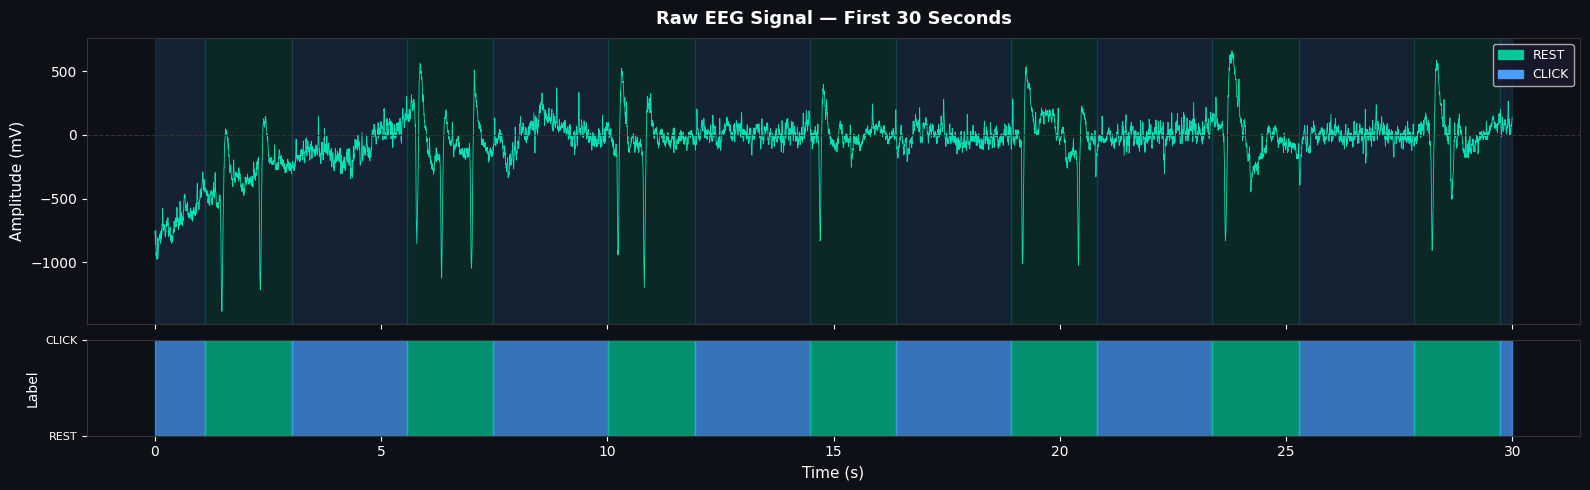

In [15]:
t = np.arange(len(signal)) / FS
window = int(30 * FS)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 5), sharex=True,
                                 gridspec_kw={'height_ratios': [3, 1]})
fig.patch.set_facecolor('#0D1117')
for ax in (ax1, ax2):
    ax.set_facecolor('#0D1117')
    ax.tick_params(colors='white'); ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')
    for spine in ax.spines.values(): spine.set_color('#333')

ax1.plot(t[:window], signal[:window], color='#00F5C4', lw=0.6, alpha=0.9)
ax1.set_ylabel('Amplitude (mV)', color='white', fontsize=11)
ax1.set_title('Raw EEG Signal — First 30 Seconds', color='white', fontsize=13, fontweight='bold', pad=10)
ax1.axhline(0, color='#333', lw=0.8, ls='--')

# Label background shading
prev_lbl = labels_raw[0]; start_t = 0
for i in range(1, window):
    if labels_raw[i] != prev_lbl or i == window-1:
        c = COLORS[prev_lbl]
        ax1.axvspan(t[start_t], t[i], alpha=0.12, color=c)
        ax2.axvspan(t[start_t], t[i], alpha=0.7,  color=c)
        prev_lbl = labels_raw[i]; start_t = i

ax2.set_yticks([0, 5])
ax2.set_yticklabels(['REST', 'CLICK'], color='white', fontsize=8)
ax2.set_ylabel('Label', color='white', fontsize=10)
ax2.set_xlabel('Time (s)', color='white', fontsize=11)

from matplotlib.patches import Patch
patches = [Patch(color=COLORS[c], label=CLASS_NAMES[c]) for c in LABEL_ORDER]
ax1.legend(handles=patches, loc='upper right', facecolor='#1A1A2E', labelcolor='white', fontsize=9)

plt.tight_layout(h_pad=0.5)
plt.show()

## Trial Segmentation

In [16]:
# Detect exact label transitions → each continuous run = one BCI trial
transitions = np.where(np.diff(labels_raw) != 0)[0] + 1
boundaries  = np.concatenate([[0], transitions, [len(labels_raw)]])

segments = []
for i in range(len(boundaries) - 1):
    start, end = int(boundaries[i]), int(boundaries[i+1])
    lbl = labels_raw[start]
    seg = signal[start:end]
    if len(seg) >= 128:                     # skip very short fragments
        segments.append((seg, int(lbl)))

print(f"Total trials detected : {len(segments)}")
from collections import Counter
dist = Counter(s[1] for s in segments)
for cls, cnt in sorted(dist.items()):
    print(f"  Class {cls} ({CLASS_NAMES[cls]:5s}): {cnt} trials, "
          f"avg {np.mean([len(s[0]) for s in segments if s[1]==cls]):.0f} samples "
          f"({np.mean([len(s[0]) for s in segments if s[1]==cls])/FS:.1f}s)")


Total trials detected : 514
  Class 0 (REST ): 256 trials, avg 488 samples (1.9s)
  Class 1 (CLICK): 258 trials, avg 648 samples (2.5s)


## Feature Engineering 
#### 42 Features per Trial

In [17]:
from scipy.signal import welch
from scipy.stats import skew, kurtosis
from scipy.integrate import trapezoid

In [18]:
# ── Feature Engineering — 42 Features per Trial ───────────
FEATURE_NAMES = []

def band_power(f, pxx, lo, hi):
    idx = (f >= lo) & (f <= hi)
    return trapezoid(pxx[idx], f[idx]) if idx.sum() > 0 else 0.0

def spectral_entropy(pxx):
    p = pxx / (pxx.sum() + 1e-10)
    return float(-np.sum(p * np.log2(p + 1e-10)))

def hjorth_params(x):
    d1 = np.diff(x); d2 = np.diff(d1)
    act  = float(np.var(x))
    mob  = float(np.sqrt(np.var(d1) / (act  + 1e-10)))
    comp = float(np.sqrt(np.var(d2) / (np.var(d1) + 1e-10)) / (mob + 1e-10))
    return act, mob, comp

def extract_features(ep):
    nperseg = min(128, len(ep))
    d1 = np.diff(ep)
    half = len(ep) // 2

    # ── Time-domain (18 features) ───────────────────────────
    td = [
        float(np.mean(ep)),          # mean amplitude
        float(np.std(ep)),           # standard deviation
        float(np.var(ep)),           # variance
        float(skew(ep)),             # skewness
        float(kurtosis(ep)),         # excess kurtosis
        float(np.sqrt(np.mean(ep**2))),           # RMS
        float(np.max(ep) - np.min(ep)),           # peak-to-peak
        float(np.mean(np.abs(ep))),               # mean absolute value
        float(np.sum(np.diff(np.sign(ep)) != 0)), # zero-crossing rate
        float(np.percentile(ep, 10)),             # 10th pctile
        float(np.percentile(ep, 25)),             # 25th pctile
        float(np.percentile(ep, 75)),             # 75th pctile
        float(np.percentile(ep, 90)),             # 90th pctile
        float(np.sum(np.abs(d1))),                # line length (complexity proxy)
        float(np.mean(ep[:half])),                # first-half mean
        float(np.mean(ep[half:])),                # second-half mean
        float(np.std(ep[:half])),                 # first-half std
        float(np.std(ep[half:])),                 # second-half std
    ]

    # ── Hjorth parameters (3 features) ─────────────────────
    act, mob, comp = hjorth_params(ep)
    hj = [act, mob, comp]

    # ── Autocorrelation lags (5 features) ──────────────────
    ac = np.correlate(ep, ep, mode='full')
    ac = ac[len(ac)//2:]
    ac = ac / (ac[0] + 1e-10)
    autocorr = [float(ac[lag]) if lag < len(ac) else 0.0
                for lag in [1, 2, 5, 10, 20]]

    # ── Frequency-domain — Welch PSD (16 features) ─────────
    f, pxx = welch(ep, fs=FS, nperseg=nperseg)
    pxx = np.maximum(pxx, 1e-12)

    d_ = band_power(f, pxx, 2,  4)    # delta
    t_ = band_power(f, pxx, 4,  8)    # theta
    a_ = band_power(f, pxx, 8,  13)   # alpha
    b_ = band_power(f, pxx, 13, 30)   # beta
    g_ = band_power(f, pxx, 30, 45)   # gamma
    tot= band_power(f, pxx, 1,  50)   # total

    fd = [
        d_, t_, a_, b_, g_, tot,              # absolute band powers
        d_/(tot+1e-10),                        # relative delta
        t_/(tot+1e-10),                        # relative theta
        a_/(tot+1e-10),                        # relative alpha
        b_/(tot+1e-10),                        # relative beta
        a_ /(b_ +1e-10),                       # alpha/beta ratio (key MI feature)
        t_ /(a_ +1e-10),                       # theta/alpha ratio
        (a_+b_)/(d_+t_+1e-10),                # high/low ratio
        spectral_entropy(pxx),                 # spectral entropy
        float(f[np.argmax(pxx)]),              # peak frequency
        float(np.sum(pxx * f) / (np.sum(pxx)+1e-10)),  # spectral centroid
    ]

    return np.array(td + hj + autocorr + fd, dtype=np.float32)

# Build global feature name list
FEATURE_NAMES = (
    ['mean','std','var','skewness','kurtosis','rms','p2p','mav','zcr',
     'pct10','pct25','pct75','pct90','line_len','h1_mean','h2_mean','h1_std','h2_std']
  + ['hjorth_activity','hjorth_mobility','hjorth_complexity']
  + [f'autocorr_lag{l}' for l in [1,2,5,10,20]]
  + ['delta','theta','alpha','beta','gamma','total_power',
     'rel_delta','rel_theta','rel_alpha','rel_beta',
     'alpha_beta_ratio','theta_alpha_ratio','hilo_ratio',
     'spectral_entropy','peak_freq','spectral_centroid']
)

X = np.array([extract_features(s[0]) for s in segments])
y = np.array([s[1] for s in segments])

print(f"Feature matrix shape: {X.shape}  (trials × features)")
print(f"Feature names: {len(FEATURE_NAMES)}")
pd.DataFrame(X, columns=FEATURE_NAMES).describe().round(3)


Feature matrix shape: (514, 42)  (trials × features)
Feature names: 42


,mean,std,var,skewness,kurtosis,rms,p2p,mav,zcr,pct10,...,rel_delta,rel_theta,rel_alpha,rel_beta,alpha_beta_ratio,theta_alpha_ratio,hilo_ratio,spectral_entropy,peak_freq,spectral_centroid
count,514.000,514.000,514.000,514.000,514.000,514.000,514.000,514.000,514.000,514.000,...,514.000,514.000,514.000,514.000,514.000,514.000,514.000,514.000,514.000,514.000
mean,-2.417,127.697,21242.459,-0.631,4.307,129.604,930.814,84.483,101.506,-111.228,...,0.298,0.357,0.122,0.140,2.039,3.234,0.506,3.424,3.424,12.269
std,34.403,70.324,22464.721,0.890,4.337,75.122,500.038,50.713,43.601,77.718,...,0.103,0.105,0.037,0.115,1.780,1.537,0.426,0.836,4.898,7.313
min,-654.126,39.888,1591.028,-4.034,-0.649,39.900,269.010,30.745,0.000,-818.506,...,0.044,0.106,0.030,0.014,0.122,1.026,0.059,1.885,2.000,3.790
25%,-4.330,58.402,3410.841,-1.275,0.657,59.091,417.102,45.349,68.000,-129.981,...,0.220,0.262,0.098,0.034,0.519,2.092,0.184,2.645,2.000,5.694
50%,0.173,132.204,17478.249,-0.537,3.253,133.063,1107.268,79.233,93.500,-89.152,...,0.297,0.356,0.119,0.084,1.358,2.967,0.344,3.116,3.000,7.670
75%,3.805,178.710,31937.369,0.114,6.703,179.720,1383.075,108.011,137.000,-65.933,...,0.363,0.457,0.146,0.240,3.294,4.025,0.734,4.235,4.000,19.142
max,59.375,442.402,195719.734,2.300,22.726,668.477,2523.645,654.126,225.000,-37.188,...,0.632,0.524,0.260,0.618,9.886,13.420,4.815,5.112,78.000,31.644


## EEG Signal Band Power Distributed per Class

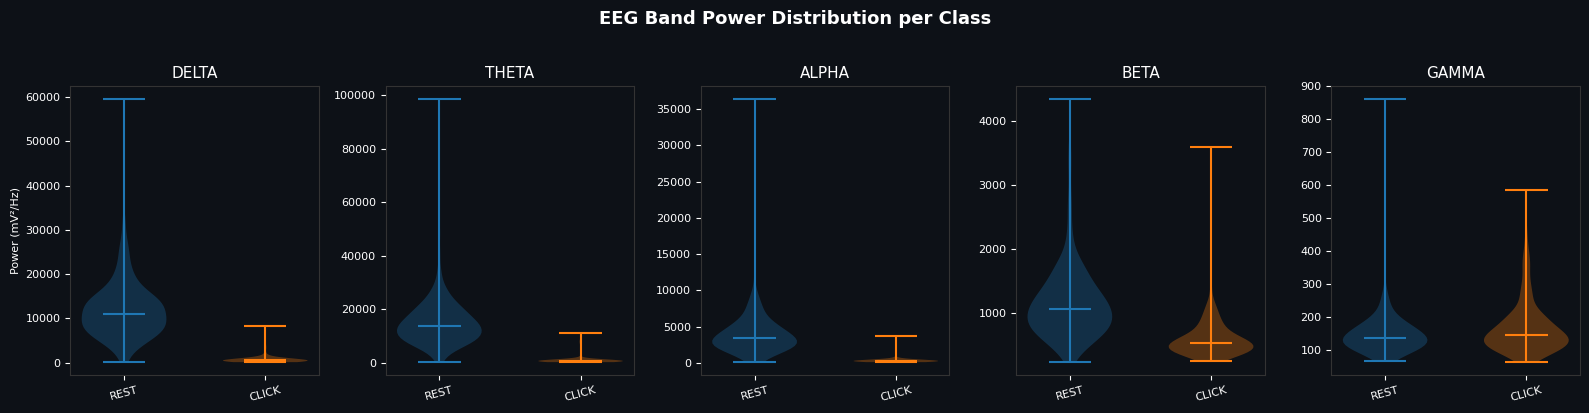

In [19]:
band_cols = ['delta','theta','alpha','beta','gamma']

feat_df = pd.DataFrame(X, columns=FEATURE_NAMES)
feat_df['Class'] = [CLASS_NAMES[yi] for yi in y]

fig, axes = plt.subplots(1, 5, figsize=(16, 4))
fig.patch.set_facecolor('#0D1117')
fig.suptitle('EEG Band Power Distribution per Class', color='white', fontsize=13, fontweight='bold', y=1.02)

for ax, band in zip(axes, band_cols):
    ax.set_facecolor('#0D1117')
    ax.tick_params(colors='white', labelsize=8)
    for spine in ax.spines.values(): spine.set_color('#333')

    for cls in ['REST', 'CLICK']:
        vals = feat_df[feat_df['Class']==cls][band].values
        c    = list(COLORS.values())[['REST','CLICK'].index(cls)]
        ax.violinplot([vals], positions=[['REST','CLICK'].index(cls)],
                      showmedians=True, widths=0.6)

    ax.set_xticks([0,1])
    ax.set_xticklabels(['REST','CLICK'], rotation=15, fontsize=8, color='white')
    ax.set_title(band.upper(), color='white', fontsize=11)
    ax.set_ylabel('Power (mV²/Hz)' if band=='delta' else '', color='white', fontsize=8)

plt.tight_layout()
plt.show()


# Model Training
### Classification Model

In [20]:
# Scaling the data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [21]:
X_scaled.shape

(514, 42)

In [22]:
# Using Ensemble Classifier Models

from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, VotingClassifier

et = ExtraTreesClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=1,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
)

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
)


### Classification Pipeline

In [23]:
# Using soft-voting ensemble where average predicted probabilities are used

ensemble = VotingClassifier(
    estimators=[('et', et), ('rf', rf)],
    voting='soft',
    n_jobs=-1,
)

In [24]:
ensemble

VotingClassifier(estimators=[('et',
                              ExtraTreesClassifier(class_weight='balanced',
                                                   n_estimators=500, n_jobs=-1,
                                                   random_state=42)),
                             ('rf',
                              RandomForestClassifier(class_weight='balanced',
                                                     n_estimators=300,
                                                     n_jobs=-1,
                                                     random_state=42))],
                 n_jobs=-1, voting='soft')

In [25]:
# 5-fold Stratified Cross-Validation

from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(ensemble, X_scaled, y, cv=cv, scoring='accuracy')

print("=" * 52)
print("  ExtraTrees + RandomForest Soft Voting Ensemble")
print("=" * 52)
print(f"  Fold accuracies : {[f'{s*100:.1f}%' for s in scores]}")
print(f"  Mean accuracy   : {scores.mean()*100:.1f}%")

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/__init__.py:16: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.2)
  from scipy.sparse import issparse
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/__init__.py:16: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.2)
  from scipy.sparse import issparse
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/__init__.py:16: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.2)
  from scipy.sparse import issparse
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/__init__.py:16: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.2)
  fr

  ExtraTrees + RandomForest Soft Voting Ensemble
  Fold accuracies : ['97.1%', '96.1%', '100.0%', '96.1%', '97.1%']
  Mean accuracy   : 97.3%


## Model Evaluation 

In [26]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [27]:
y_pred = cross_val_predict(ensemble, X_scaled, y, cv=cv, method='predict')

print("\nClassification Report:")
print(classification_report(y, y_pred,
      target_names=[CLASS_NAMES[c] for c in LABEL_ORDER],
      labels=LABEL_ORDER))

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/__init__.py:16: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.2)
  from scipy.sparse import issparse
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/__init__.py:16: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.2)
  from scipy.sparse import issparse
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/__init__.py:16: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.2)
  from scipy.sparse import issparse



Classification Report:
              precision    recall  f1-score   support

        REST       0.97      0.98      0.97       256
       CLICK       0.98      0.97      0.97       258

    accuracy                           0.97       514
   macro avg       0.97      0.97      0.97       514
weighted avg       0.97      0.97      0.97       514



#### Plot Confusion Matrix

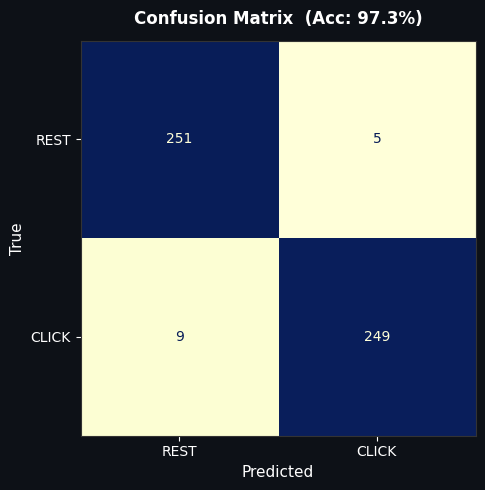

In [28]:
cm = confusion_matrix(y, y_pred, labels=LABEL_ORDER)

fig, ax = plt.subplots(figsize=(6, 5))
fig.patch.set_facecolor('#0D1117')
ax.set_facecolor('#0D1117')
ax.tick_params(colors='white')
for spine in ax.spines.values(): spine.set_color('#333')

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[CLASS_NAMES[c] for c in LABEL_ORDER]
)
disp.plot(ax=ax, colorbar=False, cmap='YlGnBu')
ax.set_title(f'Confusion Matrix  (Acc: {accuracy_score(y,y_pred)*100:.1f}%)',
             color='white', fontsize=12, fontweight='bold', pad=12)
ax.set_xlabel('Predicted', color='white', fontsize=11)
ax.set_ylabel('True',      color='white', fontsize=11)
ax.xaxis.set_tick_params(labelcolor='white')
ax.yaxis.set_tick_params(labelcolor='white')

plt.tight_layout()
plt.show()


## Saving Final Model

In [29]:
import joblib

# Save the model to a file
joblib.dump(ensemble, 'BCI_MODEL.joblib')

print("Model saved successfully!")

Model saved successfully!


In [30]:
# Loading the model
import joblib

# Load the model from the file
loaded_model = joblib.load('BCI_MODEL.joblib')


In [31]:
loaded_model

VotingClassifier(estimators=[('et',
                              ExtraTreesClassifier(class_weight='balanced',
                                                   n_estimators=500, n_jobs=-1,
                                                   random_state=42)),
                             ('rf',
                              RandomForestClassifier(class_weight='balanced',
                                                     n_estimators=300,
                                                     n_jobs=-1,
                                                     random_state=42))],
                 n_jobs=-1, voting='soft')

---
# PyTorch Deep Learning Models
Three architectures are implemented:
- **FNN** – Feedforward Neural Network on the 42 engineered features
- **CNN** – 1-D Convolutional Network on the raw EEG segment (fixed-length window)
- **Hybrid CNN + FNN** – CNN processes the raw signal; FNN processes the feature vector; outputs are fused before the final classifier


In [32]:
!pip install torch torchvision --quiet

In [33]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ── Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Check for MPS availability, then CUDA, then fallback to CPU
if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")

print(f"Device set to: {DEVICE}")

Device set to: mps


In [34]:
# ── Shared data preparation ──────────────────────────────────────────────────
# Map labels {0,5} → {0,1} for binary classification
label_map = {0: 0, 1: 1}
y_bin = np.array([label_map[yi] for yi in y], dtype=np.int64)

# ── Feature matrix (already scaled from sklearn section)
X_feat = X_scaled.astype(np.float32)            # (N, 42)
N_FEATURES = X_feat.shape[1]

# ── Raw segments → pad / truncate to a fixed window length
WIN_LEN = 256   # 1 second at 256 Hz

def pad_or_trim(seg, length=WIN_LEN):
    if len(seg) >= length:
        return seg[:length]
    return np.pad(seg, (0, length - len(seg)), mode='constant')

X_raw = np.array([pad_or_trim(s[0]) for s in segments], dtype=np.float32)  # (N, WIN_LEN)

# Z-score each raw window independently
X_raw = (X_raw - X_raw.mean(axis=1, keepdims=True)) / (X_raw.std(axis=1, keepdims=True) + 1e-8)

print(f'Feature matrix : {X_feat.shape}')
print(f'Raw EEG matrix : {X_raw.shape}')
print(f'Labels         : {y_bin.shape}  (classes: {np.unique(y_bin, return_counts=True)})')

Feature matrix : (514, 42)
Raw EEG matrix : (514, 256)
Labels         : (514,)  (classes: (array([0, 1]), array([256, 258])))


In [35]:
# ── Generic cross-validated training & evaluation ───────────────────────────

def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0
    for batch in loader:
        optimizer.zero_grad()
        *inputs, labels = [b.to(DEVICE) for b in batch]
        out = model(*inputs)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

@torch.no_grad()
def eval_model(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    for batch in loader:
        *inputs, labels = [b.to(DEVICE) for b in batch]
        out = model(*inputs)
        preds = out.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())
    return np.array(all_labels), np.array(all_preds)


def cross_validate(build_fn, build_dataset_fn, y_labels,
                   n_splits=5, epochs=80, lr=1e-3, batch_size=16):
    """Run stratified k-fold CV; returns per-fold accuracies + full OOF predictions."""
    skf   = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    oof_true, oof_pred = np.zeros(len(y_labels), dtype=int), np.zeros(len(y_labels), dtype=int)
    fold_accs = []
    train_loss_history = []

    for fold, (tr_idx, val_idx) in enumerate(skf.split(np.zeros(len(y_labels)), y_labels)):
        model = build_fn().to(DEVICE)
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

        tr_ds  = build_dataset_fn(tr_idx)
        val_ds = build_dataset_fn(val_idx)
        tr_loader  = DataLoader(tr_ds,  batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_ds, batch_size=batch_size)

        fold_losses = []
        for ep in range(epochs):
            l = train_epoch(model, tr_loader, criterion, optimizer)
            scheduler.step()
            fold_losses.append(l)

        train_loss_history.append(fold_losses)
        true_lbl, pred_lbl = eval_model(model, val_loader)
        acc = accuracy_score(true_lbl, pred_lbl)
        fold_accs.append(acc)
        oof_true[val_idx] = true_lbl
        oof_pred[val_idx] = pred_lbl
        print(f'  Fold {fold+1}/{n_splits}  val_acc={acc*100:.1f}%')

    print(f'  → Mean CV Acc: {np.mean(fold_accs)*100:.1f}% ± {np.std(fold_accs)*100:.1f}%')
    return fold_accs, oof_true, oof_pred, train_loss_history


def plot_results(model_name, fold_accs, oof_true, oof_pred, loss_history, color='#4A9EFF'):
    """Plot training curves, fold accuracies, and confusion matrix."""
    fig = plt.figure(figsize=(16, 4))
    fig.patch.set_facecolor('#0D1117')
    gs = fig.add_gridspec(1, 3, wspace=0.35)

    # --- Loss curves
    ax1 = fig.add_subplot(gs[0])
    ax1.set_facecolor('#0D1117')
    for spine in ax1.spines.values(): spine.set_color('#333')
    ax1.tick_params(colors='white')
    for i, lh in enumerate(loss_history):
        ax1.plot(lh, alpha=0.6, label=f'Fold {i+1}')
    ax1.set_title('Training Loss per Fold', color='white', fontweight='bold')
    ax1.set_xlabel('Epoch', color='white'); ax1.set_ylabel('Loss', color='white')
    ax1.legend(fontsize=7, framealpha=0.2, labelcolor='white')

    # --- Fold accuracies bar
    ax2 = fig.add_subplot(gs[1])
    ax2.set_facecolor('#0D1117')
    for spine in ax2.spines.values(): spine.set_color('#333')
    ax2.tick_params(colors='white')
    bars = ax2.bar(range(1, len(fold_accs)+1), [a*100 for a in fold_accs], color=color, alpha=0.85)
    ax2.axhline(np.mean(fold_accs)*100, color='white', linestyle='--', linewidth=1.2, label=f'Mean={np.mean(fold_accs)*100:.1f}%')
    ax2.set_ylim(0, 110)
    ax2.set_title('CV Fold Accuracies', color='white', fontweight='bold')
    ax2.set_xlabel('Fold', color='white'); ax2.set_ylabel('Accuracy (%)', color='white')
    ax2.legend(fontsize=8, framealpha=0.2, labelcolor='white')
    for bar, acc in zip(bars, fold_accs):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height()+1,
                 f'{acc*100:.0f}%', ha='center', color='white', fontsize=8)

    # --- Confusion matrix
    ax3 = fig.add_subplot(gs[2])
    ax3.set_facecolor('#0D1117')
    for spine in ax3.spines.values(): spine.set_color('#333')
    ax3.tick_params(colors='white')
    cm = confusion_matrix(oof_true, oof_pred)
    ConfusionMatrixDisplay(cm, display_labels=['REST', 'CLICK']).plot(
        ax=ax3, colorbar=False, cmap='YlGnBu')
    ax3.set_title(f'OOF Confusion Matrix  (Acc: {accuracy_score(oof_true, oof_pred)*100:.1f}%)',
                  color='white', fontweight='bold')
    ax3.set_xlabel('Predicted', color='white'); ax3.set_ylabel('True', color='white')
    ax3.xaxis.set_tick_params(labelcolor='white'); ax3.yaxis.set_tick_params(labelcolor='white')

    fig.suptitle(f'{model_name} — Results', color='white', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    print(classification_report(oof_true, oof_pred, target_names=['REST', 'CLICK']))

## 1. Feedforward Neural Network (FNN)
Takes the **42 engineered features** as input.  
Architecture: `Linear → BN → ReLU → Dropout` × 3 layers → softmax output.

In [36]:
# ── FNN Architecture ─────────────────────────────────────────────────────────
class BCIFNN(nn.Module):
    def __init__(self, in_features=42, hidden=[128, 64, 32], dropout=0.4, n_classes=2):
        super().__init__()
        layers = []
        prev = in_features
        for h in hidden:
            layers += [
                nn.Linear(prev, h),
                nn.BatchNorm1d(h),
                nn.ReLU(),
                nn.Dropout(dropout),
            ]
            prev = h
        layers.append(nn.Linear(prev, n_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


# Quick architecture summary
demo = BCIFNN()
print(demo)
total_params = sum(p.numel() for p in demo.parameters() if p.requires_grad)
print(f'\nTrainable parameters: {total_params:,}')

BCIFNN(
  (net): Sequential(
    (0): Linear(in_features=42, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.4, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.4, inplace=False)
    (12): Linear(in_features=32, out_features=2, bias=True)
  )
)

Trainable parameters: 16,354


In [37]:
# ── FNN Cross-Validation ──────────────────────────────────────────────────────
print('Training FNN (42 engineered features)...')

X_feat_t = torch.tensor(X_feat)          # (N, 42)
y_t = torch.tensor(y_bin)

def fnn_dataset(idx):
    return TensorDataset(X_feat_t[idx], y_t[idx])

fnn_accs, fnn_true, fnn_pred, fnn_loss_hist = cross_validate(
    build_fn      = lambda: BCIFNN(in_features=N_FEATURES),
    build_dataset_fn = fnn_dataset,
    y_labels      = y_bin,
    n_splits=5, epochs=500, lr=1e-3, batch_size=16,
)

Training FNN (42 engineered features)...
  Fold 1/5  val_acc=98.1%
  Fold 2/5  val_acc=96.1%
  Fold 3/5  val_acc=100.0%
  Fold 4/5  val_acc=97.1%
  Fold 5/5  val_acc=99.0%
  → Mean CV Acc: 98.1% ± 1.4%


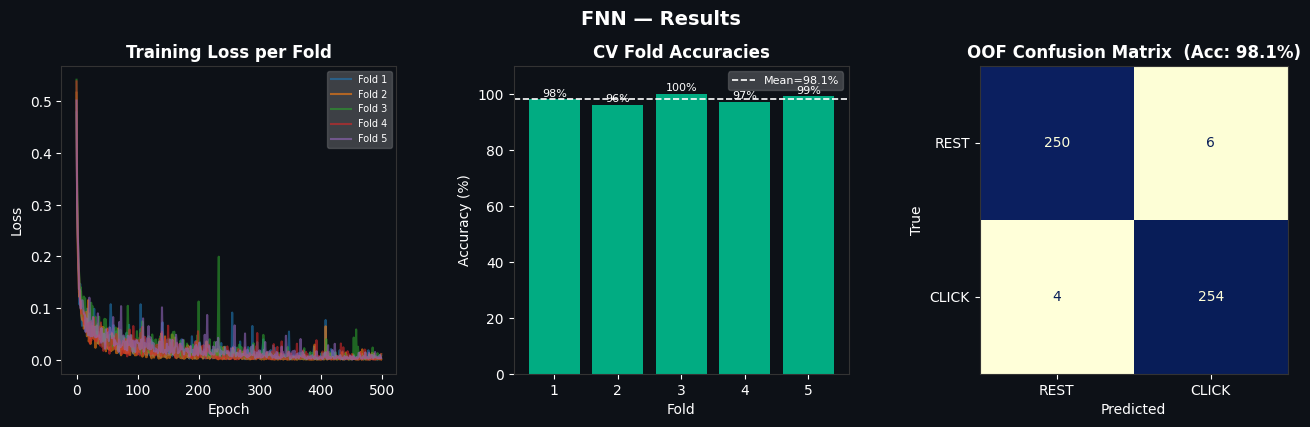

              precision    recall  f1-score   support

        REST       0.98      0.98      0.98       256
       CLICK       0.98      0.98      0.98       258

    accuracy                           0.98       514
   macro avg       0.98      0.98      0.98       514
weighted avg       0.98      0.98      0.98       514



In [38]:
plot_results('FNN', fnn_accs, fnn_true, fnn_pred, fnn_loss_hist, color='#00C896')

## 2. Convolutional Neural Network (CNN)
Takes the **raw EEG window** (256 samples) as a 1-D temporal signal.  
Architecture: Three `Conv1D → BN → ReLU → MaxPool` blocks followed by global average pooling and a linear classifier.

In [39]:
# ── CNN Architecture ──────────────────────────────────────────────────────────
class BCIConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel=7, pool=2, dropout=0.3):
        super().__init__()
        pad = kernel // 2
        self.block = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel_size=kernel, padding=pad),
            nn.BatchNorm1d(out_ch),
            nn.ReLU(),
            nn.MaxPool1d(pool),
            nn.Dropout(dropout),
        )
    def forward(self, x): return self.block(x)


class BCICNN(nn.Module):
    """
    Input shape: (batch, 1, WIN_LEN)
    Three conv blocks downsample the temporal dimension;
    global average pooling collapses to a fixed-size embedding.
    """
    def __init__(self, win_len=256, n_classes=2, dropout=0.4):
        super().__init__()
        self.encoder = nn.Sequential(
            BCIConvBlock(1,  32, kernel=15, pool=2, dropout=dropout),  # → (32, 128)
            BCIConvBlock(32, 64, kernel=9,  pool=2, dropout=dropout),  # → (64,  64)
            BCIConvBlock(64, 128,kernel=5,  pool=2, dropout=dropout),  # → (128, 32)
        )
        self.gap = nn.AdaptiveAvgPool1d(1)     # → (128, 1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, n_classes),
        )

    def forward(self, x):
        # x: (B, WIN_LEN) → add channel dim
        x = x.unsqueeze(1)          # (B, 1, WIN_LEN)
        x = self.encoder(x)
        x = self.gap(x)
        return self.classifier(x)

    def embed(self, x):
        """Return the 128-d embedding before classification (used by Hybrid)."""
        x = x.unsqueeze(1)
        x = self.encoder(x)
        x = self.gap(x)
        return x.squeeze(-1)        # (B, 128)


demo_cnn = BCICNN()
print(demo_cnn)
print(f'\nTrainable parameters: {sum(p.numel() for p in demo_cnn.parameters() if p.requires_grad):,}')

BCICNN(
  (encoder): Sequential(
    (0): BCIConvBlock(
      (block): Sequential(
        (0): Conv1d(1, 32, kernel_size=(15,), stride=(1,), padding=(7,))
        (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
        (4): Dropout(p=0.4, inplace=False)
      )
    )
    (1): BCIConvBlock(
      (block): Sequential(
        (0): Conv1d(32, 64, kernel_size=(9,), stride=(1,), padding=(4,))
        (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
        (4): Dropout(p=0.4, inplace=False)
      )
    )
    (2): BCIConvBlock(
      (block): Sequential(
        (0): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=(2,))
        (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running

In [40]:
# ── CNN Cross-Validation ──────────────────────────────────────────────────────
print('Training CNN (raw EEG windows)...')

X_raw_t = torch.tensor(X_raw)      # (N, WIN_LEN)
y_t     = torch.tensor(y_bin)

def cnn_dataset(idx):
    return TensorDataset(X_raw_t[idx], y_t[idx])

cnn_accs, cnn_true, cnn_pred, cnn_loss_hist = cross_validate(
    build_fn         = lambda: BCICNN(win_len=WIN_LEN),
    build_dataset_fn = cnn_dataset,
    y_labels         = y_bin,
    n_splits=5, epochs=500, lr=5e-4, batch_size=16,
)

Training CNN (raw EEG windows)...
  Fold 1/5  val_acc=96.1%
  Fold 2/5  val_acc=95.1%
  Fold 3/5  val_acc=96.1%
  Fold 4/5  val_acc=92.2%
  Fold 5/5  val_acc=97.1%
  → Mean CV Acc: 95.3% ± 1.7%


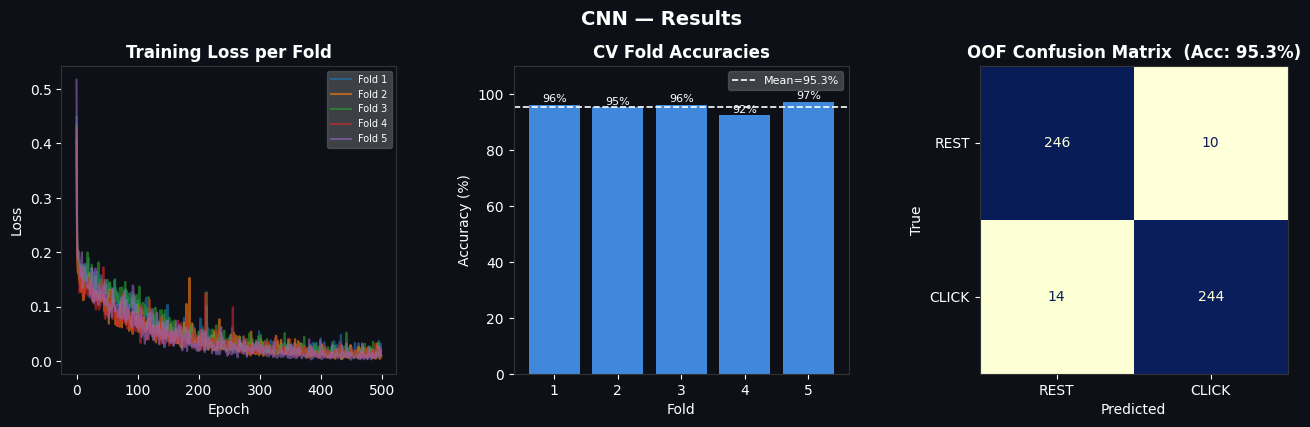

              precision    recall  f1-score   support

        REST       0.95      0.96      0.95       256
       CLICK       0.96      0.95      0.95       258

    accuracy                           0.95       514
   macro avg       0.95      0.95      0.95       514
weighted avg       0.95      0.95      0.95       514



In [41]:
plot_results('CNN', cnn_accs, cnn_true, cnn_pred, cnn_loss_hist, color='#4A9EFF')

## 3. Hybrid CNN + FNN Model
**Dual-branch architecture:**
- **CNN branch** processes the raw EEG window → 128-d temporal embedding
- **FNN branch** processes the 42 engineered features → 64-d feature embedding
- Both embeddings are **concatenated** → final MLP classifier (192-d → 64 → 2)

This lets the model jointly exploit low-level waveform patterns and hand-crafted spectral/time-domain features.

In [42]:
# ── Hybrid Architecture ───────────────────────────────────────────────────────
class BCIHybrid(nn.Module):
    """
    Dual-input model:
      raw_eeg  : (B, WIN_LEN)  → CNN branch  → 128-d
      features : (B, N_FEAT)   → FNN branch  → 64-d
    Combined   : 192-d → classifier → 2 logits
    """
    def __init__(self, win_len=256, n_feat=42, dropout=0.4, n_classes=2):
        super().__init__()

        # --- CNN branch
        self.cnn_branch = nn.Sequential(
            BCIConvBlock(1,  32, kernel=15, pool=2, dropout=dropout),
            BCIConvBlock(32, 64, kernel=9,  pool=2, dropout=dropout),
            BCIConvBlock(64, 128,kernel=5,  pool=2, dropout=dropout),
            nn.AdaptiveAvgPool1d(1),
        )  # → (B, 128, 1)

        # --- FNN branch
        self.fnn_branch = nn.Sequential(
            nn.Linear(n_feat, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout),
        )  # → (B, 64)

        # --- Fusion classifier
        self.fusion = nn.Sequential(
            nn.Linear(128 + 64, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, n_classes),
        )

    def forward(self, raw, feat):
        # CNN path
        cnn_out = self.cnn_branch(raw.unsqueeze(1))  # (B, 128, 1)
        cnn_out = cnn_out.squeeze(-1)                # (B, 128)

        # FNN path
        fnn_out = self.fnn_branch(feat)              # (B, 64)

        # Fusion
        fused = torch.cat([cnn_out, fnn_out], dim=1) # (B, 192)
        return self.fusion(fused)


demo_hybrid = BCIHybrid()
print(demo_hybrid)
print(f'\nTrainable parameters: {sum(p.numel() for p in demo_hybrid.parameters() if p.requires_grad):,}')

BCIHybrid(
  (cnn_branch): Sequential(
    (0): BCIConvBlock(
      (block): Sequential(
        (0): Conv1d(1, 32, kernel_size=(15,), stride=(1,), padding=(7,))
        (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
        (4): Dropout(p=0.4, inplace=False)
      )
    )
    (1): BCIConvBlock(
      (block): Sequential(
        (0): Conv1d(32, 64, kernel_size=(9,), stride=(1,), padding=(4,))
        (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
        (4): Dropout(p=0.4, inplace=False)
      )
    )
    (2): BCIConvBlock(
      (block): Sequential(
        (0): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=(2,))
        (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_r

In [43]:
# ── Hybrid Cross-Validation ──────────────────────────────────────────────────
print('Training Hybrid CNN+FNN...')

X_raw_t  = torch.tensor(X_raw)     # (N, WIN_LEN)
X_feat_t = torch.tensor(X_feat)    # (N, 42)
y_t      = torch.tensor(y_bin)

def hybrid_dataset(idx):
    return TensorDataset(X_raw_t[idx], X_feat_t[idx], y_t[idx])

hybrid_accs, hybrid_true, hybrid_pred, hybrid_loss_hist = cross_validate(
    build_fn         = lambda: BCIHybrid(win_len=WIN_LEN, n_feat=N_FEATURES),
    build_dataset_fn = hybrid_dataset,
    y_labels         = y_bin,
    n_splits=5, epochs=500, lr=5e-4, batch_size=16,
)

Training Hybrid CNN+FNN...
  Fold 1/5  val_acc=98.1%
  Fold 2/5  val_acc=95.1%
  Fold 3/5  val_acc=100.0%
  Fold 4/5  val_acc=96.1%
  Fold 5/5  val_acc=99.0%
  → Mean CV Acc: 97.7% ± 1.8%


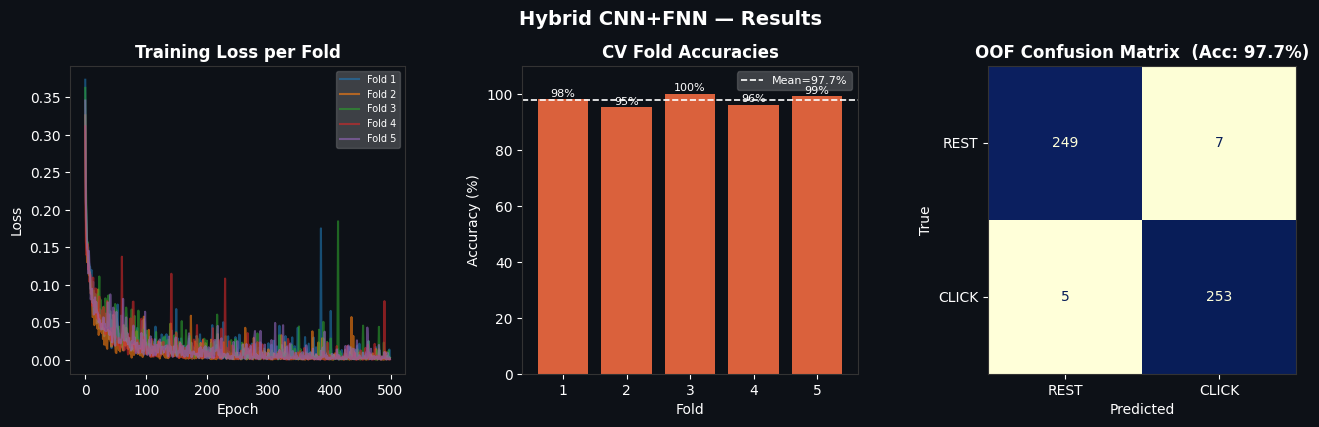

              precision    recall  f1-score   support

        REST       0.98      0.97      0.98       256
       CLICK       0.97      0.98      0.98       258

    accuracy                           0.98       514
   macro avg       0.98      0.98      0.98       514
weighted avg       0.98      0.98      0.98       514



In [44]:
plot_results('Hybrid CNN+FNN', hybrid_accs, hybrid_true, hybrid_pred, hybrid_loss_hist, color='#FF7043')

## Model Comparison

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/__init__.py:16: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.2)
  from scipy.sparse import issparse
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/__init__.py:16: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.2)
  from scipy.sparse import issparse
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/__init__.py:16: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.2)
  from scipy.sparse import issparse
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/__init__.py:16: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.2)
  fr

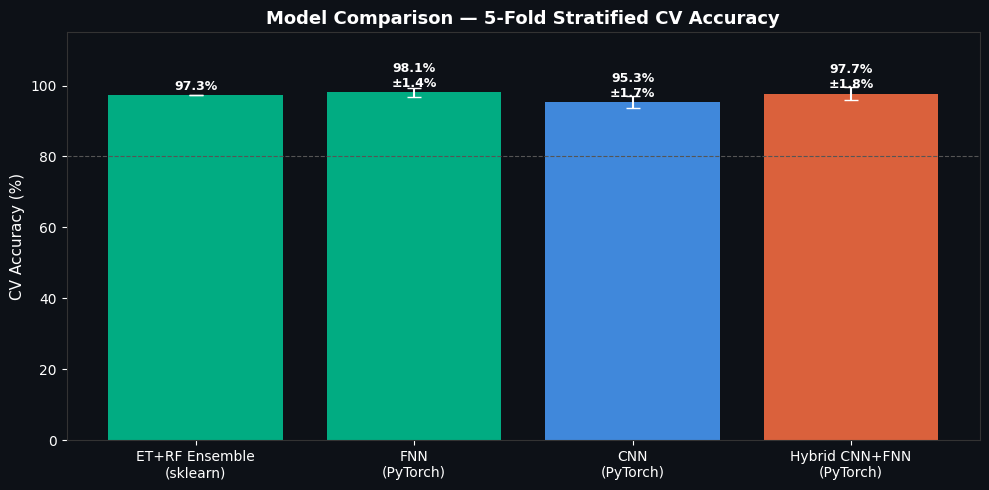

In [45]:
# ── Summary comparison across all models ─────────────────────────────────────
from sklearn.metrics import accuracy_score

# Also compute sklearn ensemble OOF accuracy for a fair comparison
from sklearn.model_selection import cross_val_predict
# Map y back to binary for sklearn ensemble (it uses the original label encoding)
y_sk_pred = cross_val_predict(
    ensemble, X_scaled, y_bin, cv=StratifiedKFold(5, shuffle=True, random_state=SEED)
)
sk_acc = accuracy_score(y_bin, y_sk_pred)

models = ['ET+RF Ensemble\n(sklearn)', 'FNN\n(PyTorch)', 'CNN\n(PyTorch)', 'Hybrid CNN+FNN\n(PyTorch)']
accs   = [sk_acc,
          np.mean(fnn_accs),
          np.mean(cnn_accs),
          np.mean(hybrid_accs)]
stds   = [0.0,
          np.std(fnn_accs),
          np.std(cnn_accs),
          np.std(hybrid_accs)]
colors_bar = ['#00C896', '#00C896', '#4A9EFF', '#FF7043']

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#0D1117')
ax.set_facecolor('#0D1117')
for spine in ax.spines.values(): spine.set_color('#333')
ax.tick_params(colors='white')

x_pos = np.arange(len(models))
bars = ax.bar(x_pos, [a*100 for a in accs], color=colors_bar, alpha=0.85,
              yerr=[s*100 for s in stds], capsize=5, error_kw=dict(ecolor='white', lw=1.5))
ax.set_xticks(x_pos)
ax.set_xticklabels(models, color='white', fontsize=10)
ax.set_ylim(0, 115)
ax.set_ylabel('CV Accuracy (%)', color='white', fontsize=11)
ax.set_title('Model Comparison — 5-Fold Stratified CV Accuracy', color='white', fontsize=13, fontweight='bold')
ax.axhline(80, color='#555', linestyle='--', linewidth=0.8)

for bar, acc, std in zip(bars, accs, stds):
    label = f'{acc*100:.1f}%' + (f'\n±{std*100:.1f}%' if std > 0 else '')
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
            label, ha='center', color='white', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

## Saving PyTorch Models

In [46]:
# ── Re-train on the full dataset and save all three PyTorch models ────────────

def train_full(build_fn, build_dataset_fn, epochs=120, lr=5e-4, batch_size=16):
    model = build_fn().to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    ds = build_dataset_fn(np.arange(len(y_bin)))
    loader = DataLoader(ds, batch_size=batch_size, shuffle=True)
    for ep in range(epochs):
        train_epoch(model, loader, criterion, optimizer)
        scheduler.step()
    return model

print('Re-training on full dataset...')

fnn_full    = train_full(lambda: BCIFNN(in_features=N_FEATURES),
                         fnn_dataset, epochs=120, lr=1e-3)
cnn_full    = train_full(lambda: BCICNN(win_len=WIN_LEN),
                         cnn_dataset, epochs=120, lr=5e-4)
hybrid_full = train_full(lambda: BCIHybrid(win_len=WIN_LEN, n_feat=N_FEATURES),
                         hybrid_dataset, epochs=120, lr=5e-4)

torch.save(fnn_full.state_dict(),    'BCI_FNN.pt')
torch.save(cnn_full.state_dict(),    'BCI_CNN.pt')
torch.save(hybrid_full.state_dict(), 'BCI_Hybrid.pt')

print('Saved: BCI_FNN.pt | BCI_CNN.pt | BCI_Hybrid.pt')

Re-training on full dataset...
Saved: BCI_FNN.pt | BCI_CNN.pt | BCI_Hybrid.pt


In [47]:
# ── Loading demo ──────────────────────────────────────────────────────────────
fnn_loaded = BCIFNN(in_features=N_FEATURES).to(DEVICE)
fnn_loaded.load_state_dict(torch.load('BCI_FNN.pt', map_location=DEVICE))
fnn_loaded.eval()

cnn_loaded = BCICNN(win_len=WIN_LEN).to(DEVICE)
cnn_loaded.load_state_dict(torch.load('BCI_CNN.pt', map_location=DEVICE))
cnn_loaded.eval()

hybrid_loaded = BCIHybrid(win_len=WIN_LEN, n_feat=N_FEATURES).to(DEVICE)
hybrid_loaded.load_state_dict(torch.load('BCI_Hybrid.pt', map_location=DEVICE))
hybrid_loaded.eval()

print('All three PyTorch models loaded successfully!')

# Quick inference example on the first sample
sample_raw  = torch.tensor(X_raw[[0]]).to(DEVICE)
sample_feat = torch.tensor(X_feat[[0]]).to(DEVICE)
LABEL_NAMES = {0: 'REST', 1: 'CLICK'}

with torch.no_grad():
    fnn_out    = fnn_loaded(sample_feat).argmax(1).item()
    cnn_out    = cnn_loaded(sample_raw).argmax(1).item()
    hybrid_out = hybrid_loaded(sample_raw, sample_feat).argmax(1).item()

print(f'\nSample 0  |  True: {LABEL_NAMES[y_bin[0]]}')
print(f'  FNN    prediction : {LABEL_NAMES[fnn_out]}')
print(f'  CNN    prediction : {LABEL_NAMES[cnn_out]}')
print(f'  Hybrid prediction : {LABEL_NAMES[hybrid_out]}')

All three PyTorch models loaded successfully!

Sample 0  |  True: CLICK
  FNN    prediction : CLICK
  CNN    prediction : CLICK
  Hybrid prediction : REST


In [48]:
import joblib
joblib.dump(scaler, 'BCI_SCALER.joblib')

['BCI_SCALER.joblib']

In [49]:
import joblib

# 1. Your model definition (example)
# ensemble = RandomForestClassifier() or similar

# 2. TRAIN THE MODEL (The missing step)
# This teaches the model using your data (X_scaled) and labels (y_bin)
ensemble.fit(X_scaled, y_bin) 

# 3. Save the model
# Only now is it safe to save, because the model has "learned" the patterns
joblib.dump(ensemble, 'BCI_MODEL.joblib')

print("Model fitted and saved successfully.")

Model fitted and saved successfully.


# Transformer Based Models

BCITransformer(
  (patch_embed): PatchEmbedding(
    (proj): Linear(in_features=16, out_features=64, bias=True)
  )
  (pos_embed): PositionalEncoding(
    (dropout): Dropout(p=0.2, inplace=False)
    (pe): Embedding(17, 64)
  )
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-2): 3 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=128, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
        (linear2): Linear(in_features=128, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.2, inplace=False)
        (dropout2): Dropout(p=0.2, inplace=False)
      )
    )
  )
  (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (cla

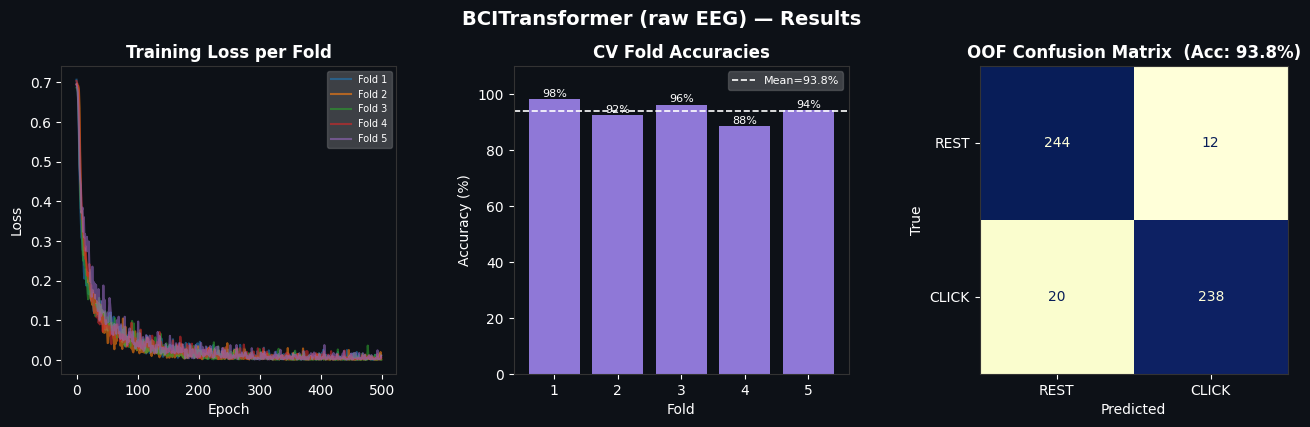

              precision    recall  f1-score   support

        REST       0.92      0.95      0.94       256
       CLICK       0.95      0.92      0.94       258

    accuracy                           0.94       514
   macro avg       0.94      0.94      0.94       514
weighted avg       0.94      0.94      0.94       514

Training BCITransformerHybrid (Transformer + FNN)...
  Fold 1/5  val_acc=99.0%
  Fold 2/5  val_acc=97.1%
  Fold 3/5  val_acc=99.0%
  Fold 4/5  val_acc=96.1%
  Fold 5/5  val_acc=98.0%
  → Mean CV Acc: 97.9% ± 1.1%


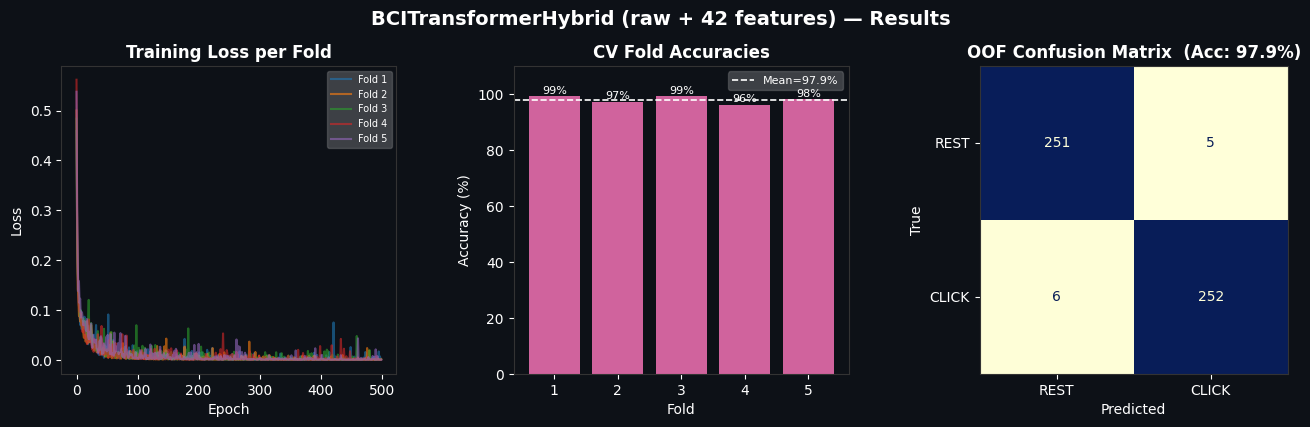

              precision    recall  f1-score   support

        REST       0.98      0.98      0.98       256
       CLICK       0.98      0.98      0.98       258

    accuracy                           0.98       514
   macro avg       0.98      0.98      0.98       514
weighted avg       0.98      0.98      0.98       514



/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/__init__.py:16: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.2)
  from scipy.sparse import issparse
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/__init__.py:16: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.2)
  from scipy.sparse import issparse
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/__init__.py:16: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.2)
  from scipy.sparse import issparse
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/__init__.py:16: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.2)
  fr

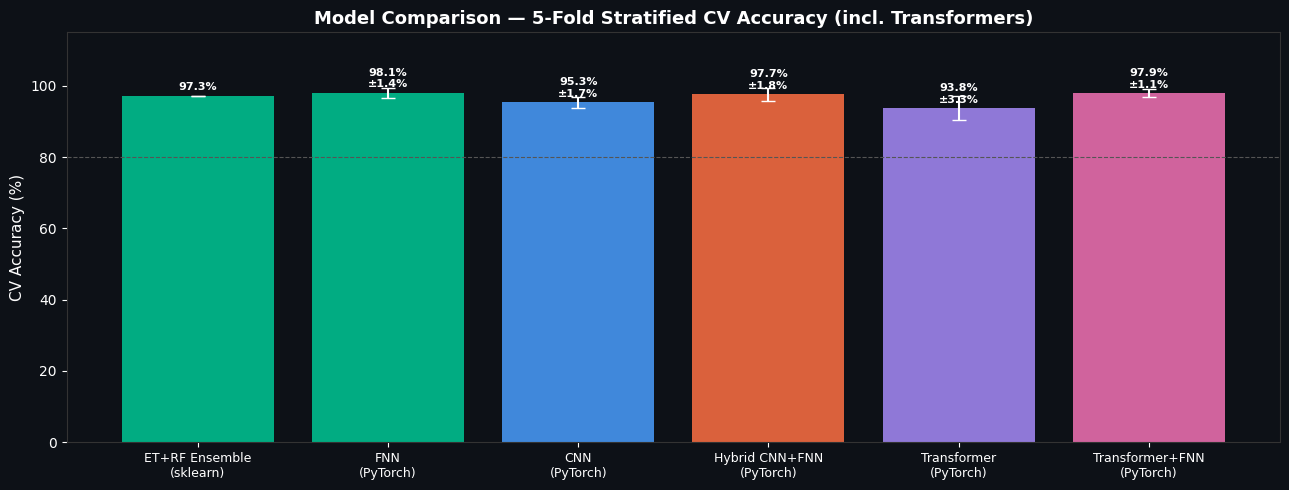

Re-training Transformer models on full dataset...
Saved: BCI_Transformer.pt | BCI_TransformerHybrid.pt

Sample 0  |  True: CLICK
  Transformer       prediction : CLICK
  TransformerHybrid prediction : REST


In [50]:
# =============================================================================
#  BCI Transformer Encoder — DROP-IN ADDITION FOR BCI_Notebook.ipynb
#  Paste each cell block after your existing PyTorch section.
# =============================================================================
#
#  Models provided
#  ───────────────
#  BCITransformer       : Transformer on raw EEG windows (patch-based)
#  BCITransformerHybrid : Transformer (raw) + FNN (42 features), fused
#
#  Both follow the same interface as BCICNN / BCIHybrid so the existing
#  cross_validate(), train_full(), save/load pattern works unchanged.
# =============================================================================

# ── Prerequisites (already imported in your notebook) ─────────────────────────
# import math, torch, torch.nn as nn, torch.optim as optim
# from torch.utils.data import TensorDataset, DataLoader
# WIN_LEN, N_FEATURES, X_raw_t, X_feat_t, y_t, y_bin, DEVICE already defined

import math
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np


# ══════════════════════════════════════════════════════════════════════════════
# CELL 1 — Building Blocks
# ══════════════════════════════════════════════════════════════════════════════

class PatchEmbedding(nn.Module):
    """
    Splits a 1-D EEG window into non-overlapping patches and projects each
    patch to d_model dimensions.

    Input  : (B, win_len)
    Output : (B, n_patches, d_model)
    """
    def __init__(self, win_len: int = 256, patch_size: int = 16, d_model: int = 64):
        super().__init__()
        assert win_len % patch_size == 0, "win_len must be divisible by patch_size"
        self.patch_size = patch_size
        self.n_patches  = win_len // patch_size            # e.g. 256//16 = 16
        self.proj       = nn.Linear(patch_size, d_model)   # one linear per patch

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, win_len)
        B = x.size(0)
        x = x.view(B, self.n_patches, self.patch_size)     # (B, n_patches, patch_size)
        return self.proj(x)                                 # (B, n_patches, d_model)


class PositionalEncoding(nn.Module):
    """
    Learnable 1-D positional embeddings (simpler and often better than
    sinusoidal for short sequences like 16–32 patches).
    """
    def __init__(self, n_positions: int, d_model: int, dropout: float = 0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        self.pe      = nn.Embedding(n_positions, d_model)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, n_patches, d_model)
        positions = torch.arange(x.size(1), device=x.device)   # (n_patches,)
        return self.dropout(x + self.pe(positions))


# ══════════════════════════════════════════════════════════════════════════════
# CELL 2 — BCITransformer (raw EEG only)
# ══════════════════════════════════════════════════════════════════════════════

class BCITransformer(nn.Module):
    """
    Patch-based Transformer Encoder for raw EEG classification.

    Architecture
    ────────────
    1. PatchEmbedding  : splits win_len into n_patches tokens
    2. [CLS] token     : prepended; its final hidden state is used for classification
    3. Learnable PE    : added to token sequence
    4. TransformerEncoder (n_layers × MultiHeadAttention + FFN)
    5. LayerNorm + Linear classifier

    Input  forward(x): x of shape (B, win_len)
    Output            : logits of shape (B, n_classes)
    """
    def __init__(
        self,
        win_len    : int   = 256,
        patch_size : int   = 16,    # → 16 patches of 16 samples each
        d_model    : int   = 64,    # embedding dimension
        n_heads    : int   = 4,     # attention heads  (d_model must be divisible)
        n_layers   : int   = 3,     # transformer encoder layers
        ffn_dim    : int   = 128,   # feed-forward hidden size inside encoder
        dropout    : float = 0.2,
        n_classes  : int   = 2,
    ):
        super().__init__()

        self.patch_embed = PatchEmbedding(win_len, patch_size, d_model)
        n_patches        = win_len // patch_size

        # [CLS] token — one learnable vector shared across batch
        self.cls_token   = nn.Parameter(torch.zeros(1, 1, d_model))
        nn.init.trunc_normal_(self.cls_token, std=0.02)

        # +1 position for CLS
        self.pos_embed   = PositionalEncoding(n_patches + 1, d_model, dropout)

        # Transformer encoder
        encoder_layer    = nn.TransformerEncoderLayer(
            d_model         = d_model,
            nhead           = n_heads,
            dim_feedforward = ffn_dim,
            dropout         = dropout,
            activation      = "gelu",
            batch_first     = True,   # (B, seq, d_model) convention
            norm_first      = True,   # Pre-LN for better gradient flow
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.norm        = nn.LayerNorm(d_model)

        # Classification head (applied to CLS token output)
        self.classifier  = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, n_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B = x.size(0)

        # 1. Patch embedding
        tokens = self.patch_embed(x)                           # (B, n_patches, d_model)

        # 2. Prepend CLS token
        cls    = self.cls_token.expand(B, -1, -1)             # (B, 1, d_model)
        tokens = torch.cat([cls, tokens], dim=1)               # (B, n_patches+1, d_model)

        # 3. Positional encoding
        tokens = self.pos_embed(tokens)                        # (B, n_patches+1, d_model)

        # 4. Transformer encoder
        tokens = self.transformer(tokens)                      # (B, n_patches+1, d_model)
        tokens = self.norm(tokens)

        # 5. Extract CLS representation and classify
        cls_out = tokens[:, 0, :]                             # (B, d_model)
        return self.classifier(cls_out)                       # (B, n_classes)

    def embed(self, x: torch.Tensor) -> torch.Tensor:
        """Return the d_model-dim CLS embedding (used by Hybrid)."""
        B      = x.size(0)
        tokens = self.patch_embed(x)
        cls    = self.cls_token.expand(B, -1, -1)
        tokens = torch.cat([cls, tokens], dim=1)
        tokens = self.pos_embed(tokens)
        tokens = self.transformer(tokens)
        tokens = self.norm(tokens)
        return tokens[:, 0, :]                                 # (B, d_model)


# Quick architecture printout
demo_transformer = BCITransformer()
print(demo_transformer)
n_params = sum(p.numel() for p in demo_transformer.parameters() if p.requires_grad)
print(f'\nTrainable parameters: {n_params:,}')


# ══════════════════════════════════════════════════════════════════════════════
# CELL 3 — BCITransformerHybrid (raw EEG + 42 features)
# ══════════════════════════════════════════════════════════════════════════════

class BCITransformerHybrid(nn.Module):
    """
    Dual-input model that fuses:
      • Transformer branch on raw EEG  → d_model-dim CLS embedding
      • FNN branch on 42 features      → feat_hidden-dim embedding
    Then concatenates and classifies.

    Usage mirrors BCIHybrid:
        logits = model(raw_window, feature_vector)
    """
    def __init__(
        self,
        win_len      : int   = 256,
        patch_size   : int   = 16,
        d_model      : int   = 64,
        n_heads      : int   = 4,
        n_layers     : int   = 3,
        ffn_dim      : int   = 128,
        n_feat       : int   = 42,
        feat_hidden  : int   = 64,
        dropout      : float = 0.2,
        n_classes    : int   = 2,
    ):
        super().__init__()

        # ── Transformer branch (identical to BCITransformer minus classifier)
        self.patch_embed = PatchEmbedding(win_len, patch_size, d_model)
        n_patches        = win_len // patch_size
        self.cls_token   = nn.Parameter(torch.zeros(1, 1, d_model))
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        self.pos_embed   = PositionalEncoding(n_patches + 1, d_model, dropout)

        encoder_layer    = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=ffn_dim,
            dropout=dropout, activation="gelu", batch_first=True, norm_first=True,
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.norm        = nn.LayerNorm(d_model)

        # ── Feature branch (compact MLP)
        self.feat_branch = nn.Sequential(
            nn.Linear(n_feat, 128),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(128, feat_hidden),
            nn.BatchNorm1d(feat_hidden),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        # ── Fusion head
        fused_dim        = d_model + feat_hidden              # 64 + 64 = 128
        self.fusion      = nn.Sequential(
            nn.Linear(fused_dim, fused_dim // 2),
            nn.LayerNorm(fused_dim // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(fused_dim // 2, n_classes),
        )

    def _transformer_embed(self, x: torch.Tensor) -> torch.Tensor:
        B      = x.size(0)
        tokens = self.patch_embed(x)
        cls    = self.cls_token.expand(B, -1, -1)
        tokens = torch.cat([cls, tokens], dim=1)
        tokens = self.pos_embed(tokens)
        tokens = self.transformer(tokens)
        return self.norm(tokens)[:, 0, :]                     # (B, d_model)

    def forward(self, raw: torch.Tensor, feat: torch.Tensor) -> torch.Tensor:
        tr_out   = self._transformer_embed(raw)               # (B, d_model)
        feat_out = self.feat_branch(feat)                     # (B, feat_hidden)
        fused    = torch.cat([tr_out, feat_out], dim=1)       # (B, d_model+feat_hidden)
        return self.fusion(fused)                             # (B, n_classes)


demo_hybrid_tr = BCITransformerHybrid()
print(demo_hybrid_tr)
n_params = sum(p.numel() for p in demo_hybrid_tr.parameters() if p.requires_grad)
print(f'\nTrainable parameters: {n_params:,}')


# ══════════════════════════════════════════════════════════════════════════════
# CELL 4 — Datasets  (reuses X_raw_t, X_feat_t, y_t from your existing code)
# ══════════════════════════════════════════════════════════════════════════════

# NOTE: X_raw_t, X_feat_t, y_t, y_bin, DEVICE must already be defined
#       (they are built in Cell 39 of your original notebook).

def transformer_dataset(idx):
    """Dataset for BCITransformer (raw only)."""
    return TensorDataset(X_raw_t[idx], y_t[idx])

def transformer_hybrid_dataset(idx):
    """Dataset for BCITransformerHybrid (raw + features)."""
    return TensorDataset(X_raw_t[idx], X_feat_t[idx], y_t[idx])


# ══════════════════════════════════════════════════════════════════════════════
# CELL 5 — Cross-Validation  (uses your existing cross_validate() helper)
# ══════════════════════════════════════════════════════════════════════════════

# ── 5a. BCITransformer (raw EEG) ──────────────────────────────────────────────
print('Training BCITransformer (patch-based Transformer on raw EEG)...')

tr_accs, tr_true, tr_pred, tr_loss_hist = cross_validate(
    build_fn         = lambda: BCITransformer(win_len=WIN_LEN),
    build_dataset_fn = transformer_dataset,
    y_labels         = y_bin,
    n_splits         = 5,
    epochs           = 500,
    lr               = 3e-4,
    batch_size       = 16,
)

# Plot results using your existing helper
plot_results(
    model_name   = 'BCITransformer (raw EEG)',
    fold_accs    = tr_accs,
    loss_history = tr_loss_hist,
    oof_true     = tr_true,
    oof_pred     = tr_pred,
    color        = '#A78BFA',   # purple
)

# ── 5b. BCITransformerHybrid (raw + features) ────────────────────────────────
print('Training BCITransformerHybrid (Transformer + FNN)...')

tr_hybrid_accs, tr_hybrid_true, tr_hybrid_pred, tr_hybrid_loss_hist = cross_validate(
    build_fn         = lambda: BCITransformerHybrid(win_len=WIN_LEN, n_feat=N_FEATURES),
    build_dataset_fn = transformer_hybrid_dataset,
    y_labels         = y_bin,
    n_splits         = 5,
    epochs           = 500,
    lr               = 3e-4,
    batch_size       = 16,
)

plot_results(
    model_name   = 'BCITransformerHybrid (raw + 42 features)',
    fold_accs    = tr_hybrid_accs,
    loss_history = tr_hybrid_loss_hist,
    oof_true     = tr_hybrid_true,
    oof_pred     = tr_hybrid_pred,
    color        = '#F472B6',   # pink
)


# ══════════════════════════════════════════════════════════════════════════════
# CELL 6 — Updated Summary Bar Chart (all 6 models)
# ══════════════════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_predict

y_sk_pred = cross_val_predict(
    ensemble, X_scaled, y_bin,
    cv=StratifiedKFold(5, shuffle=True, random_state=SEED)
)
sk_acc = accuracy_score(y_bin, y_sk_pred)

models = [
    'ET+RF Ensemble\n(sklearn)',
    'FNN\n(PyTorch)',
    'CNN\n(PyTorch)',
    'Hybrid CNN+FNN\n(PyTorch)',
    'Transformer\n(PyTorch)',
    'Transformer+FNN\n(PyTorch)',
]
accs = [
    sk_acc,
    np.mean(fnn_accs),
    np.mean(cnn_accs),
    np.mean(hybrid_accs),
    np.mean(tr_accs),
    np.mean(tr_hybrid_accs),
]
stds = [
    0.0,
    np.std(fnn_accs),
    np.std(cnn_accs),
    np.std(hybrid_accs),
    np.std(tr_accs),
    np.std(tr_hybrid_accs),
]
colors_bar = ['#00C896', '#00C896', '#4A9EFF', '#FF7043', '#A78BFA', '#F472B6']

fig, ax = plt.subplots(figsize=(13, 5))
fig.patch.set_facecolor('#0D1117')
ax.set_facecolor('#0D1117')
for spine in ax.spines.values(): spine.set_color('#333')
ax.tick_params(colors='white')

x_pos = np.arange(len(models))
bars  = ax.bar(
    x_pos, [a * 100 for a in accs],
    color=colors_bar, alpha=0.85,
    yerr=[s * 100 for s in stds], capsize=5,
    error_kw=dict(ecolor='white', lw=1.5),
)
ax.set_xticks(x_pos)
ax.set_xticklabels(models, color='white', fontsize=9)
ax.set_ylim(0, 115)
ax.set_ylabel('CV Accuracy (%)', color='white', fontsize=11)
ax.set_title(
    'Model Comparison — 5-Fold Stratified CV Accuracy (incl. Transformers)',
    color='white', fontsize=13, fontweight='bold',
)
ax.axhline(80, color='#555', linestyle='--', linewidth=0.8)

for bar, acc, std in zip(bars, accs, stds):
    label = f'{acc*100:.1f}%' + (f'\n±{std*100:.1f}%' if std > 0 else '')
    ax.text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.5,
        label, ha='center', color='white', fontsize=8, fontweight='bold',
    )

plt.tight_layout()
plt.show()


# ══════════════════════════════════════════════════════════════════════════════
# CELL 7 — Save Transformer Models
# ══════════════════════════════════════════════════════════════════════════════

print('Re-training Transformer models on full dataset...')

tr_full = train_full(
    lambda: BCITransformer(win_len=WIN_LEN),
    transformer_dataset,
    epochs=200, lr=3e-4,
)

tr_hybrid_full = train_full(
    lambda: BCITransformerHybrid(win_len=WIN_LEN, n_feat=N_FEATURES),
    transformer_hybrid_dataset,
    epochs=200, lr=3e-4,
)

torch.save(tr_full.state_dict(),        'BCI_Transformer.pt')
torch.save(tr_hybrid_full.state_dict(), 'BCI_TransformerHybrid.pt')

print('Saved: BCI_Transformer.pt | BCI_TransformerHybrid.pt')


# ══════════════════════════════════════════════════════════════════════════════
# CELL 8 — Load & Inference Demo
# ══════════════════════════════════════════════════════════════════════════════

tr_loaded = BCITransformer(win_len=WIN_LEN).to(DEVICE)
tr_loaded.load_state_dict(torch.load('BCI_Transformer.pt', map_location=DEVICE))
tr_loaded.eval()

tr_hybrid_loaded = BCITransformerHybrid(win_len=WIN_LEN, n_feat=N_FEATURES).to(DEVICE)
tr_hybrid_loaded.load_state_dict(
    torch.load('BCI_TransformerHybrid.pt', map_location=DEVICE)
)
tr_hybrid_loaded.eval()

sample_raw  = torch.tensor(X_raw[[0]]).to(DEVICE)
sample_feat = torch.tensor(X_feat[[0]]).to(DEVICE)
LABEL_NAMES = {0: 'REST', 1: 'CLICK'}

with torch.no_grad():
    tr_out        = tr_loaded(sample_raw).argmax(1).item()
    tr_hybrid_out = tr_hybrid_loaded(sample_raw, sample_feat).argmax(1).item()

print(f'\nSample 0  |  True: {LABEL_NAMES[y_bin[0]]}')
print(f'  Transformer       prediction : {LABEL_NAMES[tr_out]}')
print(f'  TransformerHybrid prediction : {LABEL_NAMES[tr_hybrid_out]}')

# Explainable AI 

▶  XAI — Ensemble (ET+RF Voting Classifier)


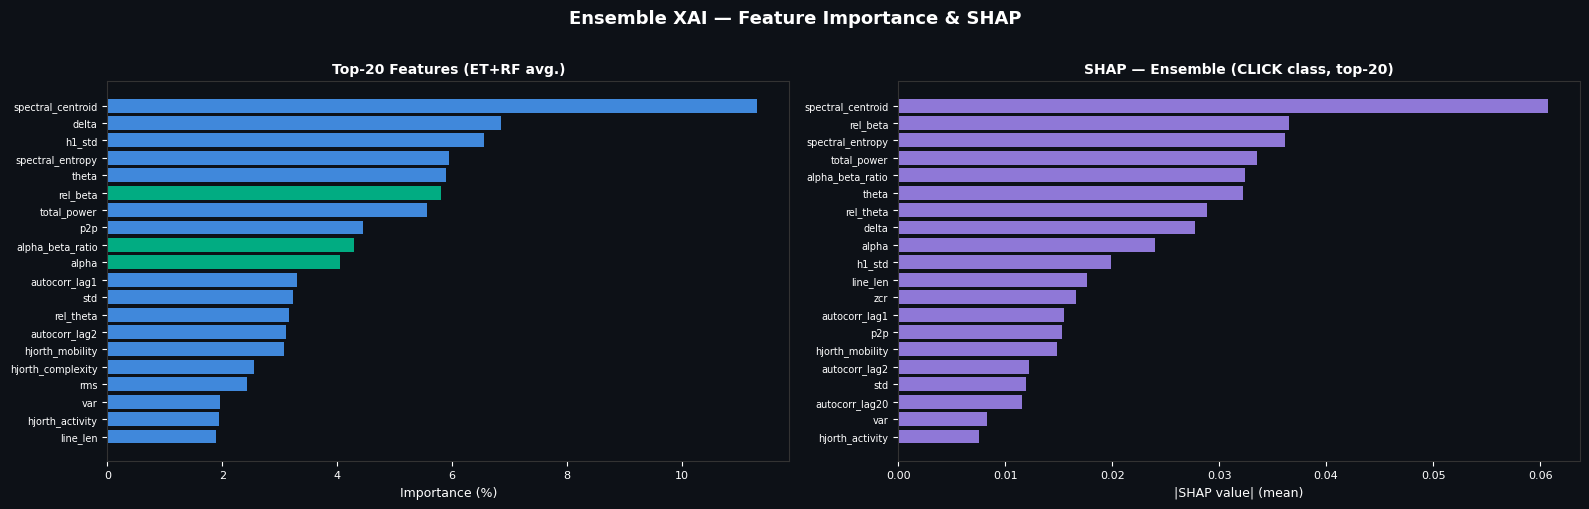

100%|===================| 1024/1028 [00:48<00:00]        

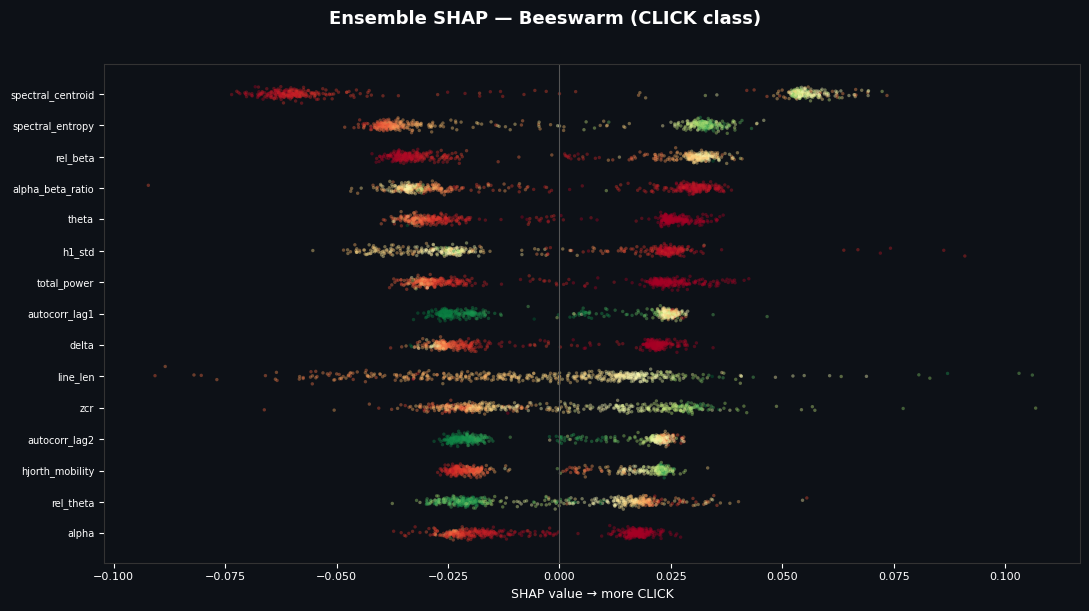

▶  XAI — FNN (42 engineered features)


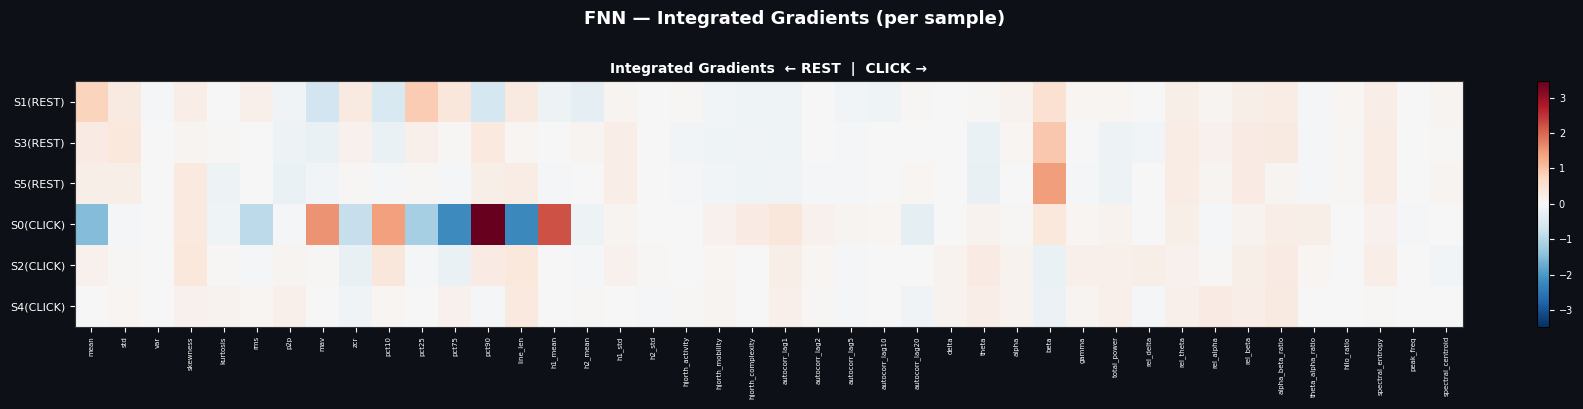

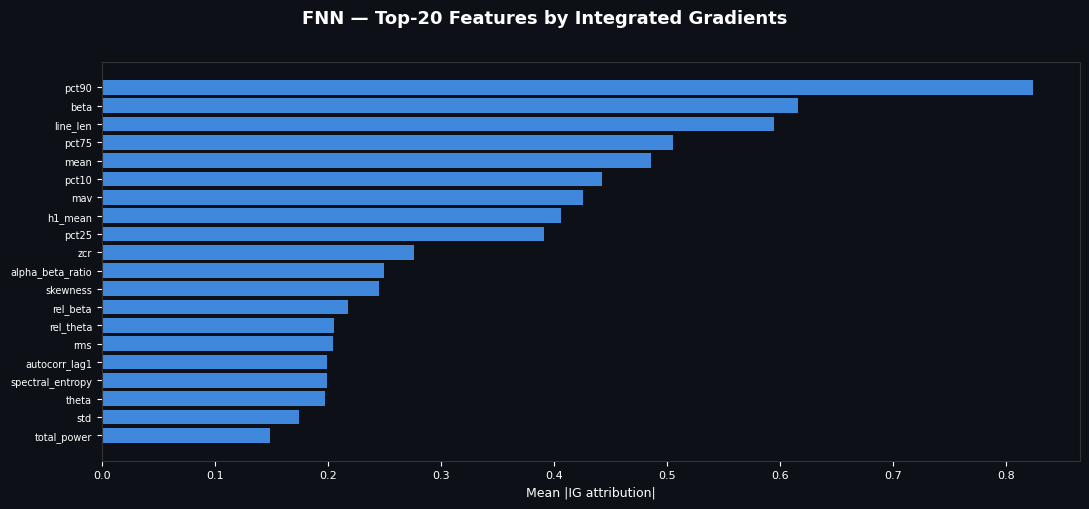

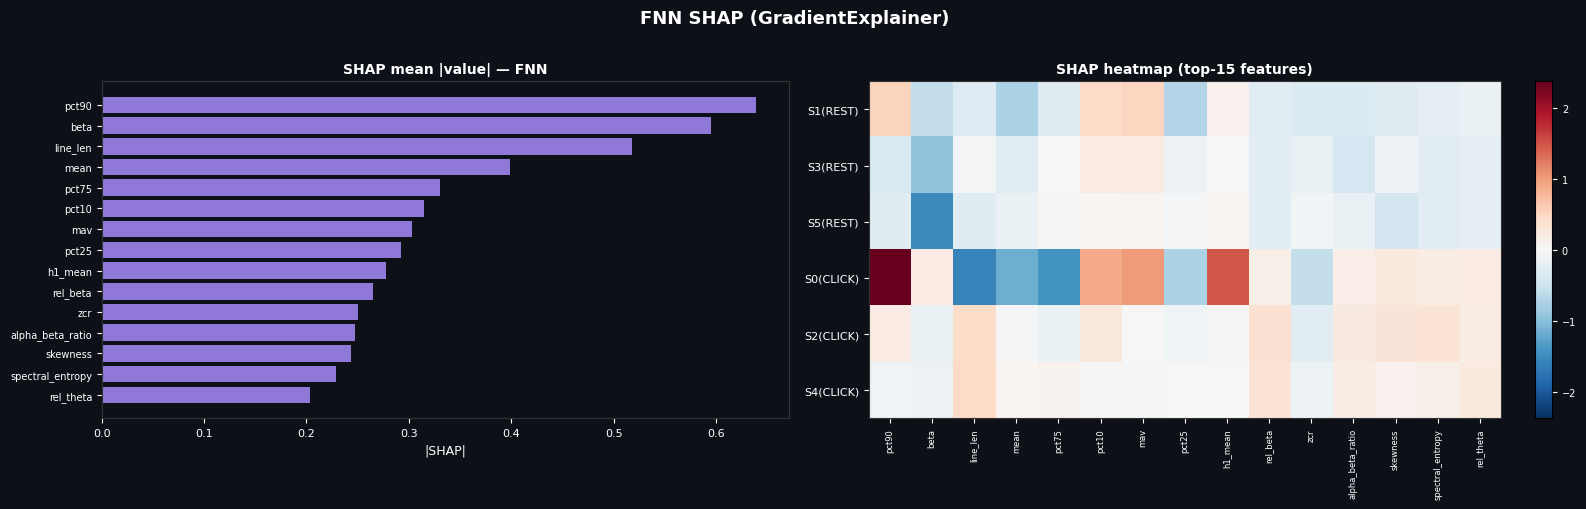

▶  XAI — CNN (raw EEG windows)


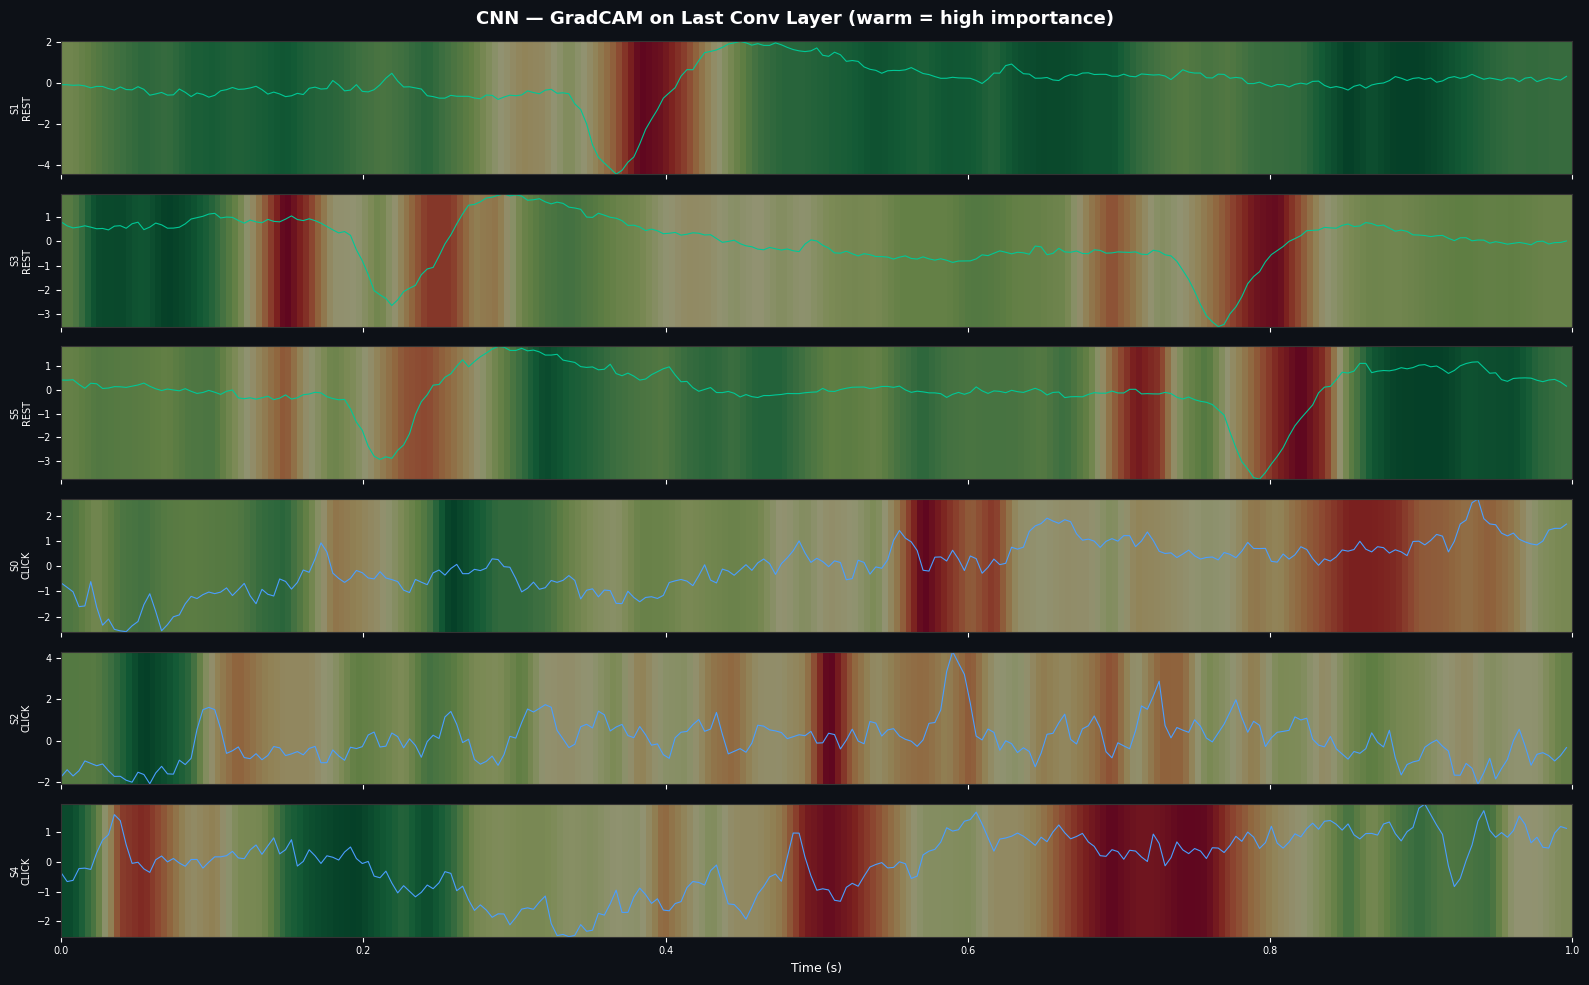

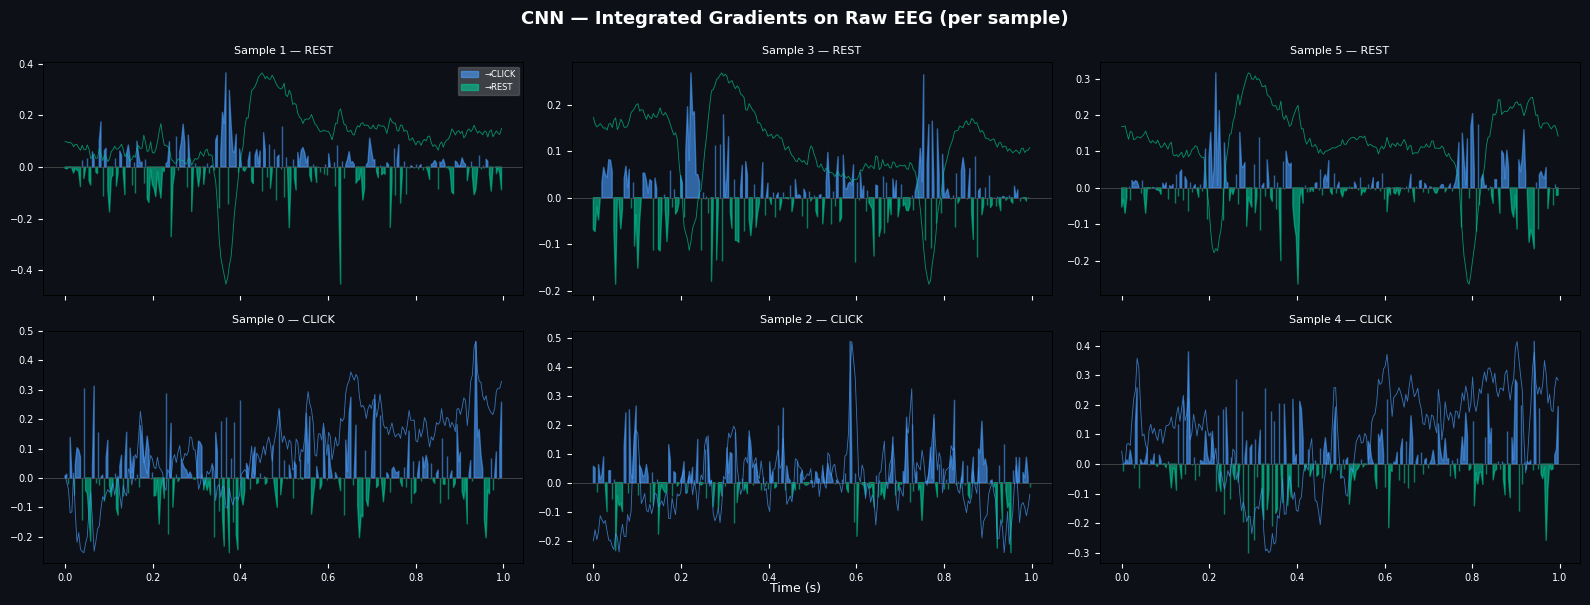

▶  XAI — Hybrid CNN+FNN


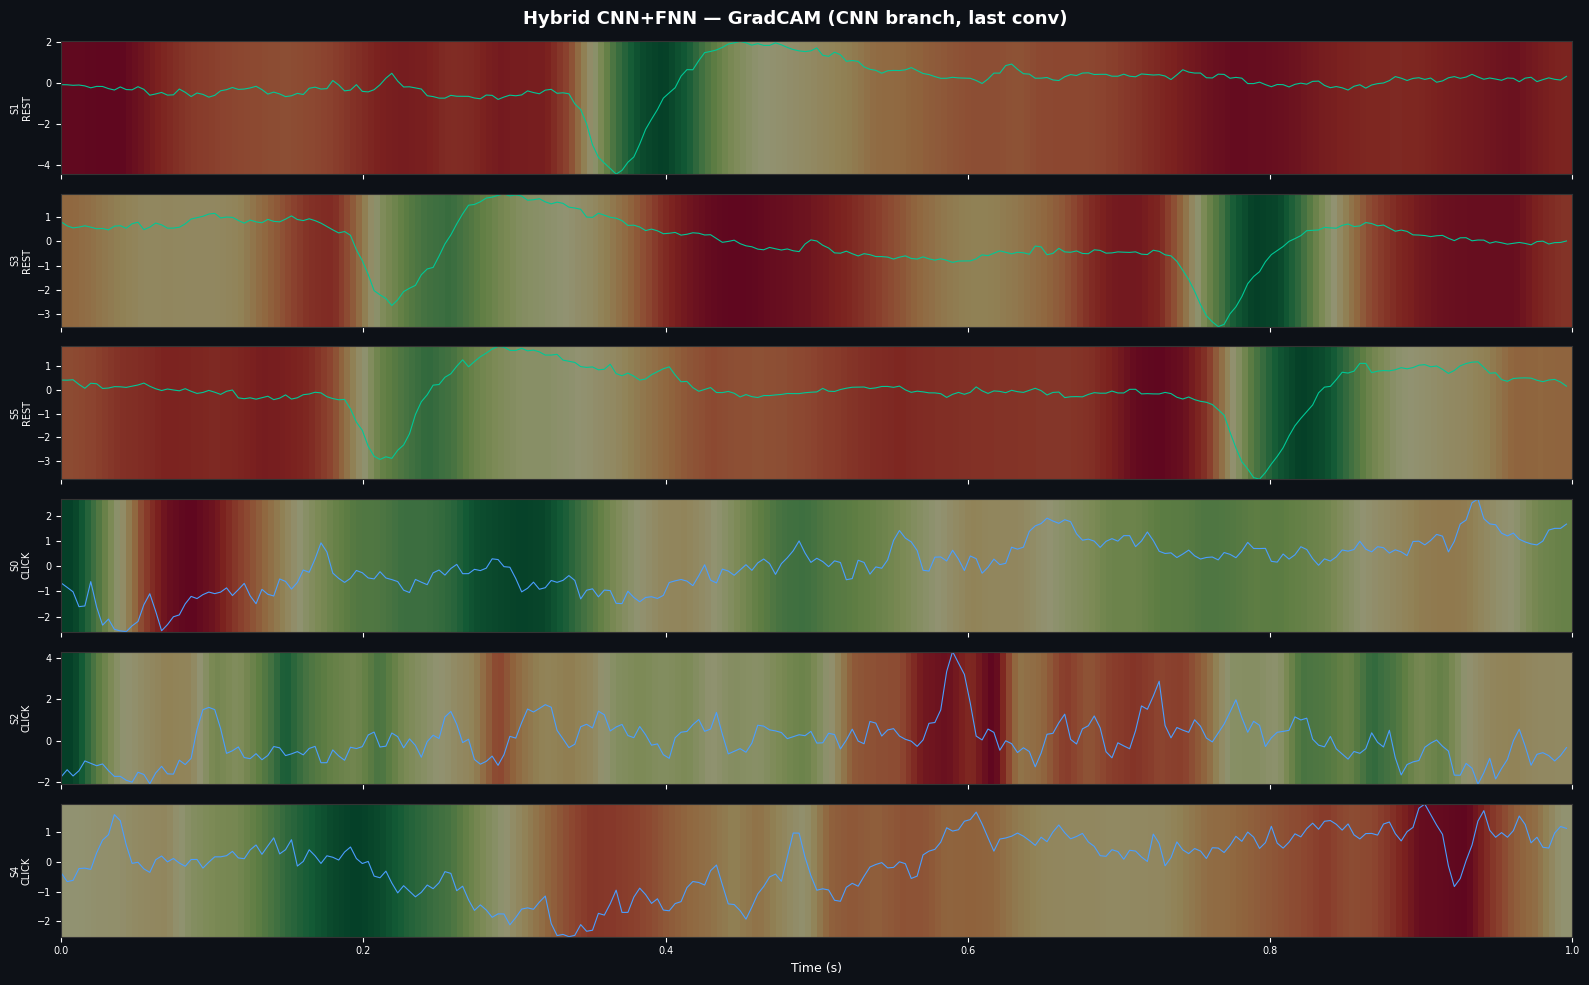

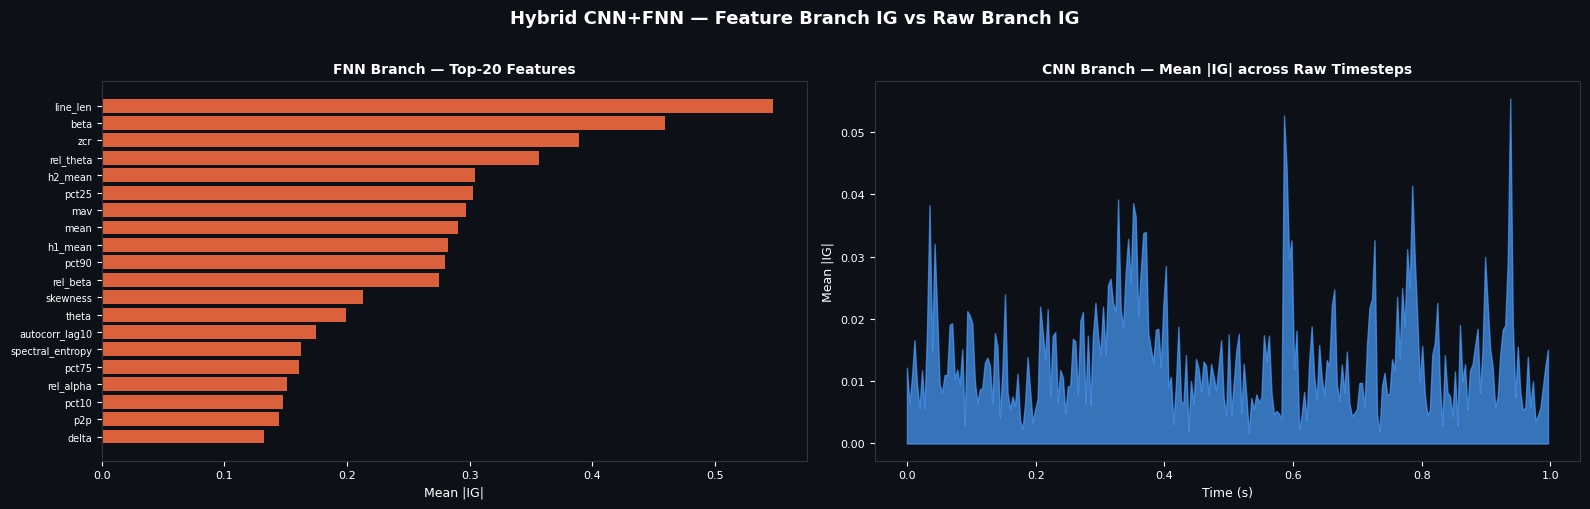

▶  XAI — BCITransformer (raw EEG)


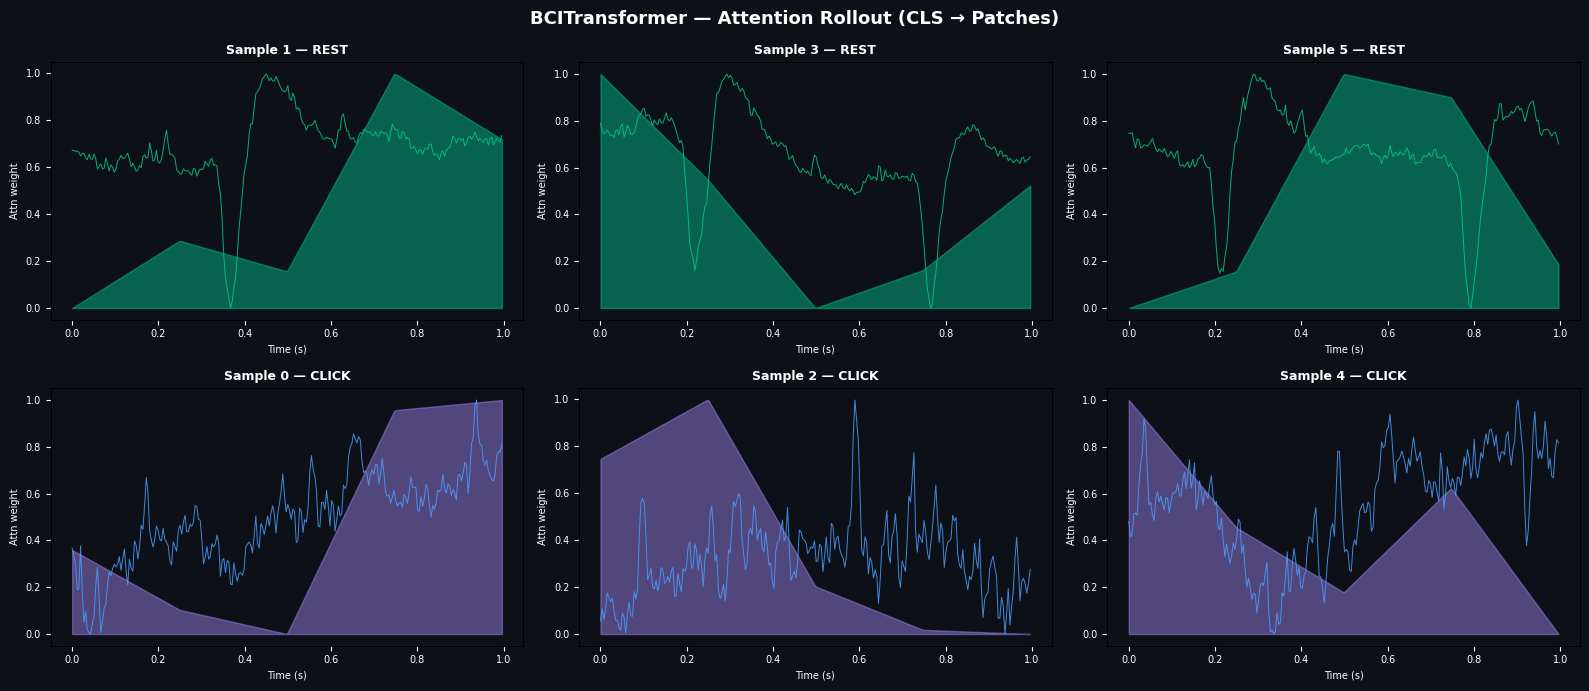

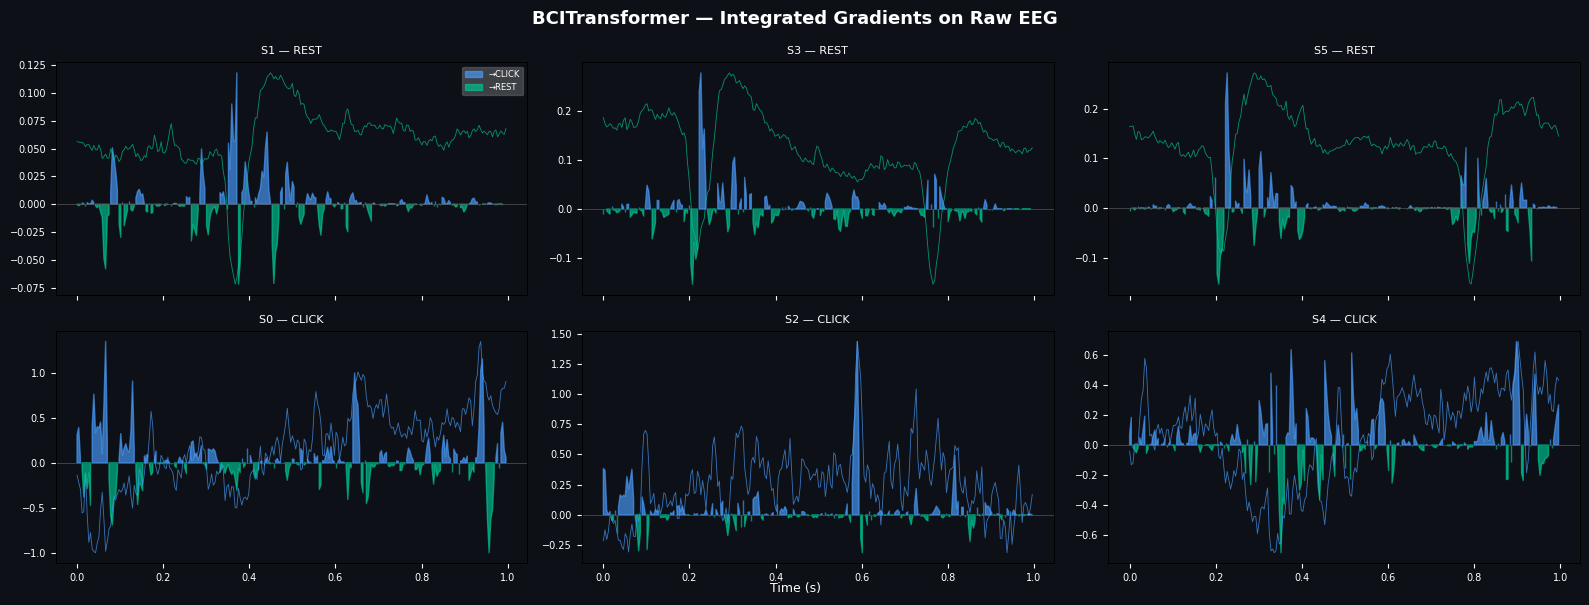

ValueError: cannot reshape array of size 1536 into shape (6,5,51)

In [51]:
# =============================================================================
#  BCI_XAI.py  —  Explainable AI for ALL BCI Models  (fully patched)
#  Run this after BCI_Notebook.ipynb cells have fully executed.
#
#  Requires in memory:
#    ensemble, fnn_full, cnn_full, hybrid_full, tr_full, tr_hybrid_full
#    X_scaled, X_feat, X_raw, y_bin, FEATURE_NAMES
#    WIN_LEN, N_FEATURES, DEVICE
#    BCIFNN, BCICNN, BCIHybrid, BCITransformer, BCITransformerHybrid
#
#  Install once (restart kernel after):
#    pip install "shap>=0.46.0" "captum>=0.7.0"
# =============================================================================


# ══════════════════════════════════════════════════════════════════════════════
# CELL 1 — Imports & shared helpers
# ══════════════════════════════════════════════════════════════════════════════

import shap
import captum
from captum.attr import IntegratedGradients, LayerGradCam, LayerAttribution

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

# ── Dark-theme palette ─────────────────────────────────────────────────────────
BG      = '#0D1117'
ACCENT1 = '#00C896'   # REST  green
ACCENT2 = '#4A9EFF'   # CLICK blue
PURPLE  = '#A78BFA'
ORANGE  = '#FF7043'
PINK    = '#F472B6'
LABEL_NAMES = {0: 'REST', 1: 'CLICK'}

def dark_fig(nrows=1, ncols=1, figsize=(14, 5), title=''):
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    fig.patch.set_facecolor(BG)
    if title:
        fig.suptitle(title, color='white', fontsize=13, fontweight='bold', y=1.01)
    for ax in (np.array(axes).ravel() if hasattr(axes, '__len__') else [axes]):
        ax.set_facecolor(BG)
        for spine in ax.spines.values():
            spine.set_color('#333')
        ax.tick_params(colors='white', labelsize=8)
    return fig, axes

def style_ax(ax, xlabel='', ylabel='', title=''):
    ax.set_xlabel(xlabel, color='white', fontsize=9)
    ax.set_ylabel(ylabel, color='white', fontsize=9)
    ax.set_title(title,  color='white', fontsize=10, fontweight='bold')

def safe_normalize(arr):
    """Normalize array to [0,1]. Uses max-min (no .ptp(), removed in NumPy 2.0)."""
    lo, hi = arr.min(), arr.max()
    return (arr - lo) / (hi - lo + 1e-8)

def norm01(v):
    """Normalize a 1-D array to [0,1] for cross-model comparison."""
    v = np.array(v, dtype=float)
    r = v.max() - v.min()           # replaces deprecated .ptp()
    return v / r if r > 0 else v

def shap_class1(shap_vals):
    """
    Extract SHAP values for class 1 (CLICK) regardless of shap version.
      Old shap  → returns list[class_idx]   → shape (n_samples, n_features)
      New shap  → returns 3-D array         → shape (n_samples, n_features, n_classes)
    Always returns ndarray of shape (n_samples, n_features).
    """
    if isinstance(shap_vals, list):
        return np.array(shap_vals[1])
    arr = np.array(shap_vals)
    if arr.ndim == 3:
        return arr[:, :, 1]
    return arr    # binary single-output fallback

# ── Demo samples: 3 REST + 3 CLICK ────────────────────────────────────────────
rest_idx  = np.where(y_bin == 0)[0][:3]
click_idx = np.where(y_bin == 1)[0][:3]
DEMO_IDX  = np.concatenate([rest_idx, click_idx])   # (6,)

t = np.arange(WIN_LEN) / 256.0    # time axis in seconds

def to_tensor(arr):
    """Convert numpy array to float32 tensor on DEVICE. MPS doesn't support float64."""
    return torch.tensor(np.array(arr, dtype=np.float32)).to(DEVICE)

from contextlib import contextmanager

@contextmanager
def on_cpu(model):
    """
    Temporarily move a model to CPU for Captum attribution calls.
    Captum internally creates float64 step-size tensors which MPS rejects.
    The model is moved back to DEVICE automatically when the block exits.
    Usage:
        with on_cpu(my_model) as m:
            ig = IntegratedGradients(m)
            attrs = ig.attribute(x_cpu, ...)
    """
    model.cpu()
    try:
        yield model
    finally:
        model.to(DEVICE)

def cpu_tensor(arr):
    """float32 CPU tensor — always pass these into Captum attribution methods."""
    return torch.tensor(np.array(arr, dtype=np.float32))   # deliberately no .to(DEVICE)


# ══════════════════════════════════════════════════════════════════════════════
# CELL 2 — XAI: Sklearn Ensemble  (Feature Importance + SHAP TreeExplainer)
# ══════════════════════════════════════════════════════════════════════════════

print("▶  XAI — Ensemble (ET+RF Voting Classifier)")

et_fitted = ensemble.estimators_[0]   # ExtraTrees
rf_fitted = ensemble.estimators_[1]   # RandomForest

# ── 2a. Combined feature importance ───────────────────────────────────────────
avg_imp = (et_fitted.feature_importances_ + rf_fitted.feature_importances_) / 2.0
order   = np.argsort(avg_imp)[::-1][:20]

fig, axes = dark_fig(1, 2, (16, 5), 'Ensemble XAI — Feature Importance & SHAP')

ax = axes[0]
colors_bar = [ACCENT1 if ('alpha' in FEATURE_NAMES[i] or 'beta' in FEATURE_NAMES[i])
              else ACCENT2 for i in order]
ax.barh([FEATURE_NAMES[i] for i in order[::-1]],
        avg_imp[order[::-1]] * 100,
        color=colors_bar[::-1], alpha=0.85)
style_ax(ax, xlabel='Importance (%)', title='Top-20 Features (ET+RF avg.)')
ax.tick_params(axis='y', labelsize=7, colors='white')

# ── 2b. SHAP TreeExplainer ────────────────────────────────────────────────────
n_bg           = min(100, len(X_scaled))
background     = X_scaled[np.random.choice(len(X_scaled), n_bg, replace=False)]
explainer      = shap.TreeExplainer(et_fitted, data=background,
                                    feature_perturbation='interventional')
shap_vals_demo = explainer.shap_values(X_scaled[DEMO_IDX])
sv_click       = shap_class1(shap_vals_demo)           # (6, 42)

mean_shap = np.abs(sv_click).mean(axis=0)              # (42,)
top_shap  = np.argsort(mean_shap)[::-1][:20].tolist()  # plain ints

ax2 = axes[1]
ax2.barh([FEATURE_NAMES[i] for i in top_shap[::-1]],
         mean_shap[top_shap[::-1]],
         color=PURPLE, alpha=0.85)
style_ax(ax2, xlabel='|SHAP value| (mean)', title='SHAP — Ensemble (CLICK class, top-20)')
ax2.tick_params(axis='y', labelsize=7, colors='white')
plt.tight_layout(); plt.show()

# ── 2c. SHAP beeswarm over all samples ────────────────────────────────────────
shap_vals_all = explainer.shap_values(X_scaled)
sv_all        = shap_class1(shap_vals_all)             # (N, 42)

shap_mean_all = np.abs(sv_all).mean(axis=0)
feat_order    = np.argsort(shap_mean_all)[::-1][:15].tolist()

fig, ax = dark_fig(1, 1, (11, 6), 'Ensemble SHAP — Beeswarm (CLICK class)')
ax = ax
for rank, fi in enumerate(feat_order[::-1]):
    vals           = sv_all[:, fi]
    feat_vals_norm = safe_normalize(X_scaled[:, fi])   # max-min, no .ptp()
    c = plt.cm.RdYlGn(feat_vals_norm)
    ax.scatter(vals,
               np.full_like(vals, rank) + np.random.randn(len(vals)) * 0.08,
               c=c, alpha=0.4, s=6, edgecolors='none')

ax.set_yticks(range(len(feat_order)))
ax.set_yticklabels([FEATURE_NAMES[i] for i in feat_order[::-1]],
                   color='white', fontsize=7)
ax.axvline(0, color='#555', lw=0.8)
style_ax(ax, xlabel='SHAP value → more CLICK', title='')
plt.tight_layout(); plt.show()


# ══════════════════════════════════════════════════════════════════════════════
# CELL 3 — XAI: FNN  (Integrated Gradients + SHAP GradientExplainer)
# ══════════════════════════════════════════════════════════════════════════════

print("▶  XAI — FNN (42 engineered features)")

fnn_full.eval()

X_feat_t_all  = to_tensor(X_feat)
X_feat_t_demo = to_tensor(X_feat[DEMO_IDX])
X_feat_demo   = X_feat_t_demo                          # alias used in later cells
baseline_feat  = torch.zeros(1, N_FEATURES, dtype=torch.float32).to(DEVICE)
targets_demo   = torch.tensor(y_bin[DEMO_IDX], dtype=torch.long).to(DEVICE)

# ── 3a. Integrated Gradients ──────────────────────────────────────────────────
_feat_demo_cpu     = cpu_tensor(X_feat[DEMO_IDX])
_baseline_feat_cpu = torch.zeros(1, N_FEATURES, dtype=torch.float32)
_targets_cpu       = torch.tensor(y_bin[DEMO_IDX], dtype=torch.long)

with on_cpu(fnn_full) as m:
    ig_fnn    = IntegratedGradients(m)
    attrs_fnn = ig_fnn.attribute(
        _feat_demo_cpu,
        baselines=_baseline_feat_cpu.expand(len(DEMO_IDX), -1),
        target=_targets_cpu,
        n_steps=50,
    ).detach().numpy()   # (6, 42)

# ── 3b. Per-sample IG heatmap ─────────────────────────────────────────────────
fig, ax = dark_fig(1, 1, (16, 4), 'FNN — Integrated Gradients (per sample)')
ax   = ax
vmax = np.abs(attrs_fnn).max()
im   = ax.imshow(attrs_fnn, aspect='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax)
ax.set_xticks(range(len(FEATURE_NAMES)))
ax.set_xticklabels(FEATURE_NAMES, rotation=90, fontsize=5, color='white')
ax.set_yticks(range(len(DEMO_IDX)))
ax.set_yticklabels([f'S{i}({LABEL_NAMES[y_bin[i]]})' for i in DEMO_IDX],
                   color='white', fontsize=8)
cb = plt.colorbar(im, ax=ax, fraction=0.015)
cb.ax.yaxis.set_tick_params(color='white')
plt.setp(cb.ax.yaxis.get_ticklabels(), color='white', fontsize=7)
style_ax(ax, title='Integrated Gradients  ← REST  |  CLICK →')
plt.tight_layout(); plt.show()

# ── 3c. Mean |IG| bar ─────────────────────────────────────────────────────────
mean_attr_fnn = np.abs(attrs_fnn).mean(axis=0)
top_fnn       = np.argsort(mean_attr_fnn)[::-1][:20].tolist()

fig, ax = dark_fig(1, 1, (11, 5), 'FNN — Top-20 Features by Integrated Gradients')
ax = ax
ax.barh([FEATURE_NAMES[i] for i in top_fnn[::-1]],
        mean_attr_fnn[top_fnn[::-1]], color=ACCENT2, alpha=0.85)
style_ax(ax, xlabel='Mean |IG attribution|', title='')
ax.tick_params(axis='y', labelsize=7, colors='white')
plt.tight_layout(); plt.show()

# ── 3d. SHAP GradientExplainer ────────────────────────────────────────────────
n_bg_feat       = min(80, len(X_feat))
background_feat = cpu_tensor(X_feat[np.random.choice(len(X_feat), n_bg_feat, replace=False)])
with on_cpu(fnn_full) as m:
    explainer_fnn = shap.GradientExplainer(m, background_feat)
    shap_fnn_raw  = explainer_fnn.shap_values(_feat_demo_cpu)
sv_fnn = shap_class1(shap_fnn_raw)

fig, axes = dark_fig(1, 2, (16, 5), 'FNN SHAP (GradientExplainer)')
top_shap_fnn = np.argsort(np.abs(sv_fnn).mean(0))[::-1][:15].tolist()

ax = axes[0]
ax.barh([FEATURE_NAMES[i] for i in top_shap_fnn[::-1]],
        np.abs(sv_fnn).mean(0)[top_shap_fnn[::-1]],
        color=PURPLE, alpha=0.85)
style_ax(ax, xlabel='|SHAP|', title='SHAP mean |value| — FNN')
ax.tick_params(axis='y', labelsize=7, colors='white')

ax   = axes[1]
vmax = np.abs(sv_fnn).max()
im   = ax.imshow(sv_fnn[:, top_shap_fnn], aspect='auto', cmap='RdBu_r',
                 vmin=-vmax, vmax=vmax)
ax.set_xticks(range(len(top_shap_fnn)))
ax.set_xticklabels([FEATURE_NAMES[i] for i in top_shap_fnn],
                   rotation=90, fontsize=6, color='white')
ax.set_yticks(range(len(DEMO_IDX)))
ax.set_yticklabels([f'S{i}({LABEL_NAMES[y_bin[i]]})' for i in DEMO_IDX],
                   color='white', fontsize=8)
cb = plt.colorbar(im, ax=ax, fraction=0.03)
cb.ax.yaxis.set_tick_params(color='white')
plt.setp(cb.ax.yaxis.get_ticklabels(), color='white', fontsize=7)
style_ax(ax, title='SHAP heatmap (top-15 features)')
plt.tight_layout(); plt.show()


# ══════════════════════════════════════════════════════════════════════════════
# CELL 4 — XAI: CNN  (GradCAM + Integrated Gradients)
# ══════════════════════════════════════════════════════════════════════════════

print("▶  XAI — CNN (raw EEG windows)")

_raw_demo_cpu     = cpu_tensor(X_raw[DEMO_IDX])
_baseline_raw_cpu = torch.zeros(1, WIN_LEN, dtype=torch.float32)

# ── 4a. GradCAM on last BCIConvBlock Conv1d ────────────────────────────────────
with on_cpu(cnn_full) as m:
    target_layer_cnn = m.encoder[2].block[0]
    gradcam_cnn      = LayerGradCam(m, target_layer_cnn)
    cam_attrs        = gradcam_cnn.attribute(_raw_demo_cpu, target=_targets_cpu)
    cam_upsampled    = LayerAttribution.interpolate(
        cam_attrs, (WIN_LEN,), interpolate_mode='linear'
    ).squeeze(1).detach().numpy()   # (6, WIN_LEN)

# ── 4b. GradCAM overlay ───────────────────────────────────────────────────────
fig, axes = plt.subplots(6, 1, figsize=(16, 10), sharex=True)
fig.patch.set_facecolor(BG)
fig.suptitle('CNN — GradCAM on Last Conv Layer (warm = high importance)',
             color='white', fontsize=13, fontweight='bold')

for row, (si, ax) in enumerate(zip(DEMO_IDX, axes)):
    ax.set_facecolor(BG)
    for sp in ax.spines.values(): sp.set_color('#333')
    ax.tick_params(colors='white', labelsize=7)
    sig_i = X_raw[si]
    cam_i = safe_normalize(cam_upsampled[row])
    ax.imshow(cam_i[np.newaxis, :], aspect='auto',
              extent=[0, WIN_LEN/256, sig_i.min(), sig_i.max()],
              cmap='RdYlGn_r', alpha=0.55, origin='lower', vmin=0, vmax=1)
    ax.plot(t, sig_i, color=ACCENT1 if y_bin[si] == 0 else ACCENT2, lw=0.8)
    ax.set_ylabel(f'S{si}\n{LABEL_NAMES[y_bin[si]]}', color='white', fontsize=7)

axes[-1].set_xlabel('Time (s)', color='white', fontsize=9)
plt.tight_layout(); plt.show()

# ── 4c. Integrated Gradients on raw EEG ──────────────────────────────────────
with on_cpu(cnn_full) as m:
    ig_cnn    = IntegratedGradients(m)
    attrs_cnn = ig_cnn.attribute(
        _raw_demo_cpu,
        baselines=_baseline_raw_cpu.expand(len(DEMO_IDX), -1),
        target=_targets_cpu,
        n_steps=50,
    ).detach().numpy()   # (6, WIN_LEN)

fig, axes = plt.subplots(2, 3, figsize=(16, 6), sharex=True)
fig.patch.set_facecolor(BG)
fig.suptitle('CNN — Integrated Gradients on Raw EEG (per sample)',
             color='white', fontsize=13, fontweight='bold')

for idx, (si, ax) in enumerate(zip(DEMO_IDX, axes.ravel())):
    ax.set_facecolor(BG)
    for sp in ax.spines.values(): sp.set_color('#333')
    ax.tick_params(colors='white', labelsize=7)
    ig_i = attrs_cnn[idx]
    ax.fill_between(t, 0, ig_i, where=ig_i > 0, color=ACCENT2, alpha=0.6, label='→CLICK')
    ax.fill_between(t, 0, ig_i, where=ig_i < 0, color=ACCENT1, alpha=0.6, label='→REST')
    ax2 = ax.twinx()
    ax2.set_facecolor(BG)
    ax2.tick_params(colors='#888', labelsize=6)
    ax2.plot(t, X_raw[si], color=ACCENT1 if y_bin[si] == 0 else ACCENT2, lw=0.6, alpha=0.7)
    ax2.set_yticks([])
    ax.axhline(0, color='#555', lw=0.5)
    ax.set_title(f'Sample {si} — {LABEL_NAMES[y_bin[si]]}', color='white', fontsize=8)
    if idx == 0: ax.legend(fontsize=6, framealpha=0.2, labelcolor='white')

fig.text(0.5, 0.01, 'Time (s)', ha='center', color='white', fontsize=9)
plt.tight_layout(); plt.show()


# ══════════════════════════════════════════════════════════════════════════════
# CELL 5 — XAI: Hybrid CNN+FNN  (GradCAM + IG on both branches)
# ══════════════════════════════════════════════════════════════════════════════

print("▶  XAI — Hybrid CNN+FNN")

hybrid_full.eval()
_raw_demo_cpu  = cpu_tensor(X_raw[DEMO_IDX])
_feat_demo_cpu = cpu_tensor(X_feat[DEMO_IDX])

# ── 5a. GradCAM — CNN branch ──────────────────────────────────────────────────
class HybridRawWrapper(nn.Module):
    def __init__(self, model, fixed_feat):
        super().__init__()
        self.model = model
        self.fixed_feat = fixed_feat
    def forward(self, raw):
        return self.model(raw, self.fixed_feat)

with on_cpu(hybrid_full) as m:
    _wrap          = HybridRawWrapper(m, _feat_demo_cpu)
    gradcam_hybrid = LayerGradCam(_wrap, m.cnn_branch[2].block[0])
    cam_hybrid     = gradcam_hybrid.attribute(_raw_demo_cpu, target=_targets_cpu)
    cam_hybrid_up  = LayerAttribution.interpolate(
        cam_hybrid, (WIN_LEN,), interpolate_mode='linear'
    ).squeeze(1).detach().numpy()

# ── 5b. IG — FNN branch ───────────────────────────────────────────────────────
class HybridFeatWrapper(nn.Module):
    def __init__(self, model, fixed_raw):
        super().__init__()
        self.model = model
        self.fixed_raw = fixed_raw          # (6, WIN_LEN)
    def forward(self, feat):
        # Captum expands feat to (6*n_steps, 42); tile fixed_raw to match
        B = feat.shape[0]
        raw = self.fixed_raw.repeat(B // self.fixed_raw.shape[0], 1)
        return self.model(raw, feat)

with on_cpu(hybrid_full) as m:
    ig_hf             = IntegratedGradients(HybridFeatWrapper(m, _raw_demo_cpu))
    attrs_hybrid_feat = ig_hf.attribute(
        _feat_demo_cpu,
        baselines=_baseline_feat_cpu.expand(len(DEMO_IDX), -1),
        target=_targets_cpu, n_steps=50,
    ).detach().numpy()   # (6, 42)

# ── 5c. IG — CNN branch ───────────────────────────────────────────────────────
class HybridRawIGWrapper(nn.Module):
    def __init__(self, model, fixed_feat):
        super().__init__()
        self.model = model
        self.fixed_feat = fixed_feat        # (6, 42)
    def forward(self, raw):
        # Captum expands raw to (6*n_steps, WIN_LEN); tile fixed_feat to match
        B = raw.shape[0]
        feat = self.fixed_feat.repeat(B // self.fixed_feat.shape[0], 1)
        return self.model(raw, feat)

with on_cpu(hybrid_full) as m:
    ig_hr             = IntegratedGradients(HybridRawIGWrapper(m, _feat_demo_cpu))
    attrs_hybrid_raw  = ig_hr.attribute(
        _raw_demo_cpu,
        baselines=_baseline_raw_cpu.expand(len(DEMO_IDX), -1),
        target=_targets_cpu, n_steps=50,
    ).detach().numpy()   # (6, WIN_LEN)

# ── 5d. GradCAM overlay ───────────────────────────────────────────────────────
fig, axes = plt.subplots(6, 1, figsize=(16, 10), sharex=True)
fig.patch.set_facecolor(BG)
fig.suptitle('Hybrid CNN+FNN — GradCAM (CNN branch, last conv)',
             color='white', fontsize=13, fontweight='bold')

for row, (si, ax) in enumerate(zip(DEMO_IDX, axes)):
    ax.set_facecolor(BG)
    for sp in ax.spines.values(): sp.set_color('#333')
    ax.tick_params(colors='white', labelsize=7)
    cam_i = safe_normalize(cam_hybrid_up[row])
    sig_i = X_raw[si]
    ax.imshow(cam_i[np.newaxis, :], aspect='auto',
              extent=[0, WIN_LEN/256, sig_i.min(), sig_i.max()],
              cmap='RdYlGn_r', alpha=0.55, origin='lower', vmin=0, vmax=1)
    ax.plot(t, sig_i, color=ACCENT1 if y_bin[si] == 0 else ACCENT2, lw=0.8)
    ax.set_ylabel(f'S{si}\n{LABEL_NAMES[y_bin[si]]}', color='white', fontsize=7)

axes[-1].set_xlabel('Time (s)', color='white', fontsize=9)
plt.tight_layout(); plt.show()

# ── 5e. FNN branch feature bar + CNN branch raw IG ────────────────────────────
mean_attr_hybrid_feat = np.abs(attrs_hybrid_feat).mean(axis=0)
top_hybrid_feat       = np.argsort(mean_attr_hybrid_feat)[::-1][:20].tolist()

fig, axes = dark_fig(1, 2, (16, 5), 'Hybrid CNN+FNN — Feature Branch IG vs Raw Branch IG')

ax = axes[0]
ax.barh([FEATURE_NAMES[i] for i in top_hybrid_feat[::-1]],
        mean_attr_hybrid_feat[top_hybrid_feat[::-1]],
        color=ORANGE, alpha=0.85)
style_ax(ax, xlabel='Mean |IG|', title='FNN Branch — Top-20 Features')
ax.tick_params(axis='y', labelsize=7, colors='white')

ax = axes[1]
ax.fill_between(t, np.abs(attrs_hybrid_raw).mean(axis=0), color=ACCENT2, alpha=0.7)
style_ax(ax, xlabel='Time (s)', ylabel='Mean |IG|',
         title='CNN Branch — Mean |IG| across Raw Timesteps')
plt.tight_layout(); plt.show()


# ══════════════════════════════════════════════════════════════════════════════
# CELL 6 — XAI: Transformer  (Attention Rollout + IG on patches)
# ══════════════════════════════════════════════════════════════════════════════

print("▶  XAI — BCITransformer (raw EEG)")

tr_full.eval()
X_raw_tr_demo = to_tensor(X_raw[DEMO_IDX])          # on DEVICE for attention rollout (no grads)
_raw_tr_cpu   = cpu_tensor(X_raw[DEMO_IDX])          # on CPU for Captum IG


import torch.nn.functional as F

def _manual_attn_rollout(transformer_layers, tokens):
    """
    Run transformer encoder layers manually, extracting attention weights
    via F.multi_head_attention_forward directly — zero hooks, zero recursion risk.
    Works for both BCITransformer and BCITransformerHybrid (same layer structure).
    Returns (B, seq, seq) rollout matrix.
    """
    rollout = None
    with torch.no_grad():
        for layer in transformer_layers:
            mha = layer.self_attn
            # Pre-norm (norm_first=True in our model)
            x_norm = layer.norm1(tokens)

            # Extract attention weights without going through the module
            _, attn_w = F.multi_head_attention_forward(
                x_norm, x_norm, x_norm,
                embed_dim_to_check  = mha.embed_dim,
                num_heads           = mha.num_heads,
                in_proj_weight      = mha.in_proj_weight,
                in_proj_bias        = mha.in_proj_bias,
                bias_k              = mha.bias_k,
                bias_v              = mha.bias_v,
                add_zero_attn       = mha.add_zero_attn,
                dropout_p           = 0.0,
                out_proj_weight     = mha.out_proj.weight,
                out_proj_bias       = mha.out_proj.bias,
                need_weights        = True,
                average_attn_weights= True,
            )   # attn_w: (B, seq, seq)

            # Run the full layer normally to get correct hidden state for next layer
            tokens = layer(tokens)

            # Accumulate rollout: A = 0.5*A + 0.5*I, then multiply
            A = attn_w.cpu()
            I = torch.eye(A.size(-1)).unsqueeze(0)
            A = 0.5 * A + 0.5 * I
            A = A / A.sum(dim=-1, keepdim=True)
            rollout = A if rollout is None else torch.bmm(rollout, A)

    return rollout   # (B, seq, seq)


def get_attention_rollout(model, x_input):
    """Attention rollout for BCITransformer."""
    model.eval()
    with torch.no_grad():
        B      = x_input.size(0)
        tokens = model.patch_embed(x_input)
        cls    = model.cls_token.expand(B, -1, -1)
        tokens = torch.cat([cls, tokens], dim=1)
        tokens = model.pos_embed(tokens)

    rollout = _manual_attn_rollout(model.transformer.layers, tokens)
    return rollout[:, 0, 1:].numpy()   # (B, n_patches)


def get_tr_hybrid_attn_rollout(model, raw_input, feat_input):
    """Attention rollout for BCITransformerHybrid (Transformer branch only)."""
    model.eval()
    with torch.no_grad():
        B      = raw_input.size(0)
        tokens = model.patch_embed(raw_input)
        cls    = model.cls_token.expand(B, -1, -1)
        tokens = torch.cat([cls, tokens], dim=1)
        tokens = model.pos_embed(tokens)

    rollout = _manual_attn_rollout(model.transformer.layers, tokens)
    return rollout[:, 0, 1:].numpy()   # (B, n_patches)


attn_rollout = get_attention_rollout(tr_full, X_raw_tr_demo)
N_PATCHES    = attn_rollout.shape[1]

# ── 6a. Attention rollout overlay (per sample) ────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 7))
fig.patch.set_facecolor(BG)
fig.suptitle('BCITransformer — Attention Rollout (CLS → Patches)',
             color='white', fontsize=13, fontweight='bold')

for idx, (si, ax) in enumerate(zip(DEMO_IDX, axes.ravel())):
    ax.set_facecolor(BG)
    for sp in ax.spines.values(): sp.set_color('#333')
    ax.tick_params(colors='white', labelsize=7)

    attn_i  = safe_normalize(attn_rollout[idx])
    attn_up = np.interp(np.linspace(0, N_PATCHES - 1, WIN_LEN),
                        np.arange(N_PATCHES), attn_i)

    ax.fill_between(t, attn_up, alpha=0.45,
                    color=PURPLE if y_bin[si] == 1 else ACCENT1)
    ax2 = ax.twinx()
    ax2.set_facecolor(BG)
    ax2.plot(t, X_raw[si],
             color=ACCENT1 if y_bin[si] == 0 else ACCENT2, lw=0.7, alpha=0.85)
    ax2.set_yticks([])
    ax2.tick_params(colors='#888', labelsize=6)

    ax.set_xlabel('Time (s)', color='white', fontsize=7)
    ax.set_ylabel('Attn weight', color='white', fontsize=7)
    ax.set_title(f'Sample {si} — {LABEL_NAMES[y_bin[si]]}',
                 color='white', fontsize=9, fontweight='bold')

plt.tight_layout(); plt.show()

# ── 6b. Integrated Gradients on raw EEG ──────────────────────────────────────
with on_cpu(tr_full) as m:
    ig_tr    = IntegratedGradients(m)
    attrs_tr = ig_tr.attribute(
        _raw_tr_cpu,
        baselines=_baseline_raw_cpu.expand(len(DEMO_IDX), -1),
        target=_targets_cpu,
        n_steps=50,
    ).detach().numpy()   # (6, WIN_LEN)

fig, axes = plt.subplots(2, 3, figsize=(16, 6), sharex=True)
fig.patch.set_facecolor(BG)
fig.suptitle('BCITransformer — Integrated Gradients on Raw EEG',
             color='white', fontsize=13, fontweight='bold')

for idx, (si, ax) in enumerate(zip(DEMO_IDX, axes.ravel())):
    ax.set_facecolor(BG)
    for sp in ax.spines.values(): sp.set_color('#333')
    ax.tick_params(colors='white', labelsize=7)
    ig_i = attrs_tr[idx]
    ax.fill_between(t, 0, ig_i, where=ig_i > 0, color=ACCENT2, alpha=0.65, label='→CLICK')
    ax.fill_between(t, 0, ig_i, where=ig_i < 0, color=ACCENT1, alpha=0.65, label='→REST')
    ax2 = ax.twinx()
    ax2.set_facecolor(BG)
    ax2.plot(t, X_raw[si],
             color=ACCENT1 if y_bin[si] == 0 else ACCENT2, lw=0.6, alpha=0.7)
    ax2.set_yticks([])
    ax2.tick_params(colors='#888', labelsize=6)
    ax.axhline(0, color='#555', lw=0.5)
    ax.set_title(f'S{si} — {LABEL_NAMES[y_bin[si]]}', color='white', fontsize=8)
    if idx == 0: ax.legend(fontsize=6, framealpha=0.2, labelcolor='white')

fig.text(0.5, 0.01, 'Time (s)', ha='center', color='white', fontsize=9)
plt.tight_layout(); plt.show()

# ── 6c. Patch-level mean |IG| ─────────────────────────────────────────────────
patch_size    = WIN_LEN // N_PATCHES
patch_ig      = np.abs(attrs_tr).reshape(len(DEMO_IDX), N_PATCHES, patch_size).mean(axis=2)
mean_patch_ig = patch_ig.mean(axis=0)
patch_ms      = np.arange(N_PATCHES) * (1000 / 256 * patch_size)

fig, ax = dark_fig(1, 1, (10, 4), 'BCITransformer — Mean |IG| per EEG Patch')
ax = ax
ax.bar(patch_ms, mean_patch_ig,
       width=1000 / 256 * patch_size * 0.85,
       color=PURPLE, alpha=0.85)
style_ax(ax, xlabel='Patch start (ms)', ylabel='Mean |IG|', title='')
plt.tight_layout(); plt.show()


# ══════════════════════════════════════════════════════════════════════════════
# CELL 7 — XAI: TransformerHybrid  (Attention Rollout + IG both branches)
# ══════════════════════════════════════════════════════════════════════════════

print("▶  XAI — BCITransformerHybrid (raw + 42 features)")

tr_hybrid_full.eval()

attn_hybrid = get_tr_hybrid_attn_rollout(
    tr_hybrid_full,
    X_raw_tr_demo,
    to_tensor(X_feat[DEMO_IDX]),
)

# ── 7a. IG — feature branch ───────────────────────────────────────────────────
class TrHybridFeatWrapper(nn.Module):
    def __init__(self, model, fixed_raw):
        super().__init__()
        self.model = model
        self.fixed_raw = fixed_raw          # (6, WIN_LEN)
    def forward(self, feat):
        B = feat.shape[0]
        raw = self.fixed_raw.repeat(B // self.fixed_raw.shape[0], 1)
        return self.model(raw, feat)

with on_cpu(tr_hybrid_full) as m:
    ig_trh_feat    = IntegratedGradients(TrHybridFeatWrapper(m, _raw_tr_cpu))
    attrs_trh_feat = ig_trh_feat.attribute(
        _feat_demo_cpu,
        baselines=_baseline_feat_cpu.expand(len(DEMO_IDX), -1),
        target=_targets_cpu, n_steps=50,
    ).detach().numpy()   # (6, 42)

# ── 7b. IG — raw (Transformer) branch ────────────────────────────────────────
class TrHybridRawWrapper(nn.Module):
    def __init__(self, model, fixed_feat):
        super().__init__()
        self.model = model
        self.fixed_feat = fixed_feat        # (6, 42)
    def forward(self, raw):
        B = raw.shape[0]
        feat = self.fixed_feat.repeat(B // self.fixed_feat.shape[0], 1)
        return self.model(raw, feat)

with on_cpu(tr_hybrid_full) as m:
    ig_trh_raw    = IntegratedGradients(TrHybridRawWrapper(m, _feat_demo_cpu))
    attrs_trh_raw = ig_trh_raw.attribute(
        _raw_tr_cpu,
        baselines=_baseline_raw_cpu.expand(len(DEMO_IDX), -1),
        target=_targets_cpu, n_steps=50,
    ).detach().numpy()   # (6, WIN_LEN)

# ── 7c. Full XAI dashboard ────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 10))
fig.patch.set_facecolor(BG)
fig.suptitle('BCITransformerHybrid — XAI Dashboard',
             color='white', fontsize=14, fontweight='bold')
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

patch_ms   = np.arange(N_PATCHES) * (1000 / 256 * (WIN_LEN // N_PATCHES))
rest_rows  = [i for i, si in enumerate(DEMO_IDX) if y_bin[si] == 0]
click_rows = [i for i, si in enumerate(DEMO_IDX) if y_bin[si] == 1]

# ① Attention rollout per class
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_facecolor(BG)
for sp in ax1.spines.values(): sp.set_color('#333')
ax1.tick_params(colors='white', labelsize=7)
ax1.plot(patch_ms, attn_hybrid[rest_rows].mean(0),  color=ACCENT1, lw=2, label='REST')
ax1.plot(patch_ms, attn_hybrid[click_rows].mean(0), color=ACCENT2, lw=2, label='CLICK')
ax1.legend(fontsize=8, framealpha=0.2, labelcolor='white')
style_ax(ax1, xlabel='Patch start (ms)', ylabel='Attn weight',
         title='① Attention Rollout (mean per class)')

# ② Raw IG per class
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_facecolor(BG)
for sp in ax2.spines.values(): sp.set_color('#333')
ax2.tick_params(colors='white', labelsize=7)
ax2.fill_between(t, np.abs(attrs_trh_raw[rest_rows]).mean(0),
                 color=ACCENT1, alpha=0.5, label='REST')
ax2.fill_between(t, np.abs(attrs_trh_raw[click_rows]).mean(0),
                 color=ACCENT2, alpha=0.5, label='CLICK')
ax2.legend(fontsize=8, framealpha=0.2, labelcolor='white')
style_ax(ax2, xlabel='Time (s)', ylabel='Mean |IG|',
         title='② Raw IG — Transformer Branch')

# ③ Feature IG bar (top-12)
ax3 = fig.add_subplot(gs[0, 2])
ax3.set_facecolor(BG)
for sp in ax3.spines.values(): sp.set_color('#333')
ax3.tick_params(colors='white', labelsize=7)
mean_feat_attr = np.abs(attrs_trh_feat).mean(0)
top_feat       = np.argsort(mean_feat_attr)[::-1][:12].tolist()
ax3.barh([FEATURE_NAMES[i] for i in top_feat[::-1]],
         mean_feat_attr[top_feat[::-1]], color=PINK, alpha=0.85)
style_ax(ax3, xlabel='Mean |IG|', title='③ Feature IG — FNN Branch (top-12)')
ax3.tick_params(axis='y', labelsize=6, colors='white')

# ④ Attention heatmap
ax4 = fig.add_subplot(gs[1, :2])
ax4.set_facecolor(BG)
for sp in ax4.spines.values(): sp.set_color('#333')
ax4.tick_params(colors='white', labelsize=7)
im = ax4.imshow(attn_hybrid, aspect='auto', cmap='plasma',
                extent=[0, WIN_LEN, len(DEMO_IDX), 0])
ax4.set_xticks(np.linspace(0, WIN_LEN, 9))
ax4.set_xticklabels([f'{int(v/256*1000)}ms' for v in np.linspace(0, WIN_LEN, 9)],
                    color='white', fontsize=7)
ax4.set_yticks(range(len(DEMO_IDX)))
ax4.set_yticklabels([f'S{si}({LABEL_NAMES[y_bin[si]]})' for si in DEMO_IDX],
                    color='white', fontsize=7)
cb = plt.colorbar(im, ax=ax4, fraction=0.015)
cb.ax.yaxis.set_tick_params(color='white')
plt.setp(cb.ax.yaxis.get_ticklabels(), color='white', fontsize=7)
style_ax(ax4, title='④ Attention Rollout Heatmap (all 6 samples)')

# ⑤ REST vs CLICK feature IG
ax5 = fig.add_subplot(gs[1, 2])
ax5.set_facecolor(BG)
for sp in ax5.spines.values(): sp.set_color('#333')
ax5.tick_params(colors='white', labelsize=6)
rest_fa  = np.abs(attrs_trh_feat[rest_rows]).mean(0)
click_fa = np.abs(attrs_trh_feat[click_rows]).mean(0)
top_both = np.argsort(rest_fa + click_fa)[::-1][:10].tolist()
xp       = np.arange(len(top_both))
ax5.barh(xp + 0.2, click_fa[top_both[::-1]], 0.35, color=ACCENT2, alpha=0.85, label='CLICK')
ax5.barh(xp - 0.2, rest_fa[top_both[::-1]],  0.35, color=ACCENT1, alpha=0.85, label='REST')
ax5.set_yticks(xp)
ax5.set_yticklabels([FEATURE_NAMES[i] for i in top_both[::-1]], fontsize=6, color='white')
ax5.legend(fontsize=7, framealpha=0.2, labelcolor='white')
style_ax(ax5, xlabel='Mean |IG|', title='⑤ Feature IG: REST vs CLICK')

plt.savefig('BCI_TransformerHybrid_XAI_Dashboard.png', dpi=150,
            bbox_inches='tight', facecolor=BG)
plt.show()


# ══════════════════════════════════════════════════════════════════════════════
# CELL 8 — Global Summary: all feature-based models side-by-side
# ══════════════════════════════════════════════════════════════════════════════

print("▶  Global XAI Summary — feature importance across all models")

all_importances = {
    'Ensemble\n(ET+RF)'               : avg_imp,
    'FNN\n(IG)'                       : mean_attr_fnn,
    'Hybrid CNN+FNN\n(FNN branch IG)' : np.abs(attrs_hybrid_feat).mean(0),
    'Transformer+FNN\n(FNN branch IG)': np.abs(attrs_trh_feat).mean(0),
}

normed    = {k: norm01(v) for k, v in all_importances.items()}

# Union of top-15 from every model
union_top = set()
for v in normed.values():
    union_top.update(np.argsort(v)[::-1][:15].tolist())
union_top   = sorted(union_top)
feat_labels = [FEATURE_NAMES[i] for i in union_top]

fig, ax = dark_fig(1, 1, (16, 7), 'Global Feature Importance — All Feature-Based Models')
ax           = ax
model_colors = [ACCENT1, ACCENT2, ORANGE, PINK]
n_models     = len(normed)
bar_w        = 0.8 / n_models
x            = np.arange(len(union_top))

for mi, (model_name, imp) in enumerate(normed.items()):
    offset = (mi - n_models / 2 + 0.5) * bar_w
    ax.bar(x + offset,
           imp[union_top],
           bar_w,
           label=model_name.replace('\n', ' '),
           color=model_colors[mi],
           alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(feat_labels, rotation=90, fontsize=7, color='white')
ax.set_ylabel('Normalized importance', color='white', fontsize=9)
ax.legend(fontsize=8, framealpha=0.2, labelcolor='white', loc='upper right', ncol=2)
ax.axhline(0, color='#555', lw=0.5)
plt.tight_layout()
plt.savefig('BCI_Global_XAI_Summary.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

print("\n✅  XAI complete!")
print("   Saved: BCI_TransformerHybrid_XAI_Dashboard.png")
print("   Saved: BCI_Global_XAI_Summary.png")

In [ ]:
# pip install --force-reinstall "scipy==1.13.1"